# Reducing AI Carbon Footprint: A Study of DistilBERT for Mental Health App Sentiment Analysis.

### Benchmarking DistilBERT Against Seven Frontier LLMs on 200,000 Mental Health App Reviews from 73 Applications.

## Project Aim

This notebook fine-tunes **DistilBERT**, a distilled, 66M-parameter version of BERT for **rating and sentiment prediction on mental health app reviews**, and benchmarks it against seven large language models (GPT-3.5 Instruct, GPT-3.5 Turbo, GPT-4, Gemini 1.5 Flash, Gemini 1.5 Pro, LLaMA 3.1 8B, LLaMA 3.3 70B) whose predictions are already bundled with the dataset.

The central question is a carbon-efficiency one: *can a small, task-specific model match or approach the performance of much larger, general-purpose LLMs at a fraction of the training and inference cost?*

## Dataset

**MHARD - Mental Health App Reviews Dataset** (Wang et al., ICWSM 2025). 200,972 user reviews scraped from 73 mental health apps on the Google Play Store between 2011 and 2023. Each review carries a user-given 1–5 star rating as ground truth, plus seven LLM-predicted ratings.

## Experimental Design

1. **Task A - 5-class ordinal classification:** predict the exact star rating (1–5).
2. **Task B - 3-class sentiment classification:** collapse ratings into negative (1–2), neutral (3), positive (4–5).

Both heads are fine-tuned from `distilbert-base-uncased` on the same stratified 80/10/10 split.

## Metrics

- Accuracy, weighted F1, macro F1
- Mean Absolute Error (MAE) - meaningful for the ordinal 5-class task
- Cohen's κ - agreement between DistilBERT and each LLM
- Confusion matrices per task
- **Carbon emissions** (kg CO₂eq) via CodeCarbon, for both training and inference
- Model size, parameter count, inference latency

## Expected Contribution

A reproducible head-to-head comparison showing that a fine-tuned DistilBERT can deliver competitive mental-health-domain review classification at an order-of-magnitude lower carbon and compute cost than frontier LLMs.

### Step 1: Environment setup (mount Drive + install packages)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install the libraries we need across the whole pipeline.
!pip install -q transformers datasets evaluate accelerate
!pip install -q scikit-learn wordcloud codecarbon
!pip install -q -U transformers huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 167.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 133.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 52.2 MB/s eta 0:00:00


### Step 2: Imports, seeds, and device check

In [4]:
# Core Python / data stack
import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# PyTorch + Hugging Face
import torch
import transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
)
from datasets import Dataset, DatasetDict
import evaluate

# Scikit-learn — splits, encoding, evaluation metrics, baselines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)

# Silence noisy deprecation warnings that clutter notebook output
warnings.filterwarnings("ignore")

# --- Reproducibility ---
# We fix every source of randomness so a reviewer, you, (or me in six months) can re-run
# and get the same splits, the same weights at initialisation, and the same metrics.
RANDOM_SEED = 42
set_seed(RANDOM_SEED)          # sets torch, numpy, and python hashseed via HF helper
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# --- Device check ---
# DistilBERT on 200k rows is painful on CPU. A T4 GPU (free Colab) or better is expected.
# print the device so we can screenshot it for the methodology section of MY paper
# (hardware specs directly affect the emissions conversion CodeCarbon applies).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 70)
print("ENVIRONMENT CHECK")
print("=" * 70)
print(f"Transformers version : {transformers.__version__}")
print(f"PyTorch version      : {torch.__version__}")
print(f"Device               : {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU                  : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version         : {torch.version.cuda}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU memory           : {total_mem:.2f} GB")
print(f"Random seed          : {RANDOM_SEED}")
print("=" * 70)

ENVIRONMENT CHECK
Transformers version : 5.6.2
PyTorch version      : 2.10.0+cu128
Device               : cuda
GPU                  : Tesla T4
CUDA version         : 12.8
GPU memory           : 14.56 GB
Random seed          : 42


### Step 3: Load the MHARD dataset

In [5]:
# Path to the CSV you already uploaded to Drive
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/DistilBERT/MHARD_dataset.csv"

# Load the full dataset. Note: MHARD already has a proper UID column, so we do NOT
# pass index_col=0
df = pd.read_csv(CSV_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Rows x Columns : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
print("=" * 70)

DATASET LOADED
Rows x Columns : 200,972 rows  x  16 columns
Memory usage   : 141.6 MB


In [6]:
# Column-by-column type report.
# Helps us confirm: rating is integer, LLM preds are numeric, text columns are strings.
print("Columns and dtypes:")
print("-" * 70)
for col, dtype in df.dtypes.items():
    non_null = df[col].notna().sum()
    print(f"  {col:<22} {str(dtype):<10}  non-null: {non_null:>7,}")
print("-" * 70)

Columns and dtypes:
----------------------------------------------------------------------
  UID                    int64       non-null: 200,972
  app_name               object      non-null: 200,972
  rating                 int64       non-null: 200,972
  date                   object      non-null: 200,972
  review                 object      non-null: 200,951
  review_cleaned         object      non-null: 200,732
  likes                  int64       non-null: 200,972
  response_date          object      non-null:  52,363
  response               object      non-null:  52,363
  pred_gpt3.5instruct    float64     non-null: 200,667
  pred_gpt3.5turbo       float64     non-null: 200,781
  pred_gpt4              float64     non-null: 200,471
  pred_gemini1.5flash    float64     non-null: 198,569
  pred_gemini1.5pro      float64     non-null: 200,918
  pred_llama3.1_8b       float64     non-null: 190,543
  pred_llama3.3_70b      float64     non-null: 200,087
-----------------------------

In [7]:
# First few rows
# pandas truncates long review text by default, so widen the display.
pd.set_option("display.max_colwidth", 200)
df.head(3)

,UID,app_name,rating,date,review,review_cleaned,likes,response_date,response,pred_gpt3.5instruct,pred_gpt3.5turbo,pred_gpt4,pred_gemini1.5flash,pred_gemini1.5pro,pred_llama3.1_8b,pred_llama3.3_70b
0,1,chiku,5,"August 17, 2020","I'm digging it. journaling everything I do during the day. my only complaint is sometimes when editing, it's hard to scroll down to see the end of the text. the scroll bar is invisible on the far ...",im digging journaling everything day complaint sometimes editing hard scroll see end text scroll bar invisible far right side sometimes cant get work properly save scroll edit might getting used i...,30,"August 23, 2020","We have fixed the issue in our latest update (version 5.2) Thank you so much for your valuable feedback, it helped us improve the app. If there is anything else we can help you with, let us know a...",4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,2,chiku,4,"December 22, 2020","I really like this app, however, the awesome smiley graphic is a bit unnerving. All of the other ones are cute, but the awesome guy really freaks me out and I think it should be redesigned. I've n...",really like app however awesome smiley graphic bit unnerving one cute awesome guy really freak think redesigned ive narrowed handful apps reflectly like setup chiku term layout journal ability fav...,18,"December 22, 2020","Thank you so much for taking out time to write a detailed review. We have forwarded it to our developers, and will definately fix the issues you are facing in our upcoming update. If there is anyt...",4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,3,chiku,5,"March 02, 2022","I love this. It's so calming, and relaxing, and definitely one of my favorites. My only problem with it is that even with the unlimited subscription I bought, it only saves my first story. I try t...",love calming relaxing definitely one favorite problem even unlimited subscription bought save first story try journal wont save anyone know way fix really love app edit anyone else problem try uni...,62,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [8]:
# Quick comparison: raw review vs cleaned review on the same row.
# This is a teaching moment — the 'review_cleaned' column has already had
# stopwords, punctuation and casing removed by the dataset authors. We need to
# decide later which one to feed DistilBERT. Previewing a couple makes the choice
# concrete rather than abstract.
for i in [0, 100, 500]:
    print(f"--- Row {i} | rating = {df.loc[i, 'rating']} | app = {df.loc[i, 'app_name']} ---")
    print(f"RAW     : {df.loc[i, 'review']}")
    print(f"CLEANED : {df.loc[i, 'review_cleaned']}")
    print()

--- Row 0 | rating = 5 | app = chiku ---
RAW     : I'm digging it. journaling everything I do during the day. my only complaint is sometimes when editing, it's hard to scroll down to see the end of the text. the scroll bar is invisible on the far right side but sometimes i can't get it to work properly and have to save, scroll then edit again. it might be me just getting used to it so I'll update this if i figure out it's user error.
CLEANED : im digging journaling everything day complaint sometimes editing hard scroll see end text scroll bar invisible far right side sometimes cant get work properly save scroll edit might getting used ill update figure user error

--- Row 100 | rating = 5 | app = chiku ---
RAW     : Well I hardly use any of the features. I use it as a mood tracker but the options u can select and stuff are cool
CLEANED : well hardly use feature use mood tracker option u select stuff cool

--- Row 500 | rating = 5 | app = chiku ---
RAW     : I love it
CLEANED : love



### Step 4: Missing value analysis

In [9]:
# Raw counts and percentages per column.
# We want to know which columns are (a) required for training, (b) required for
# evaluation against LLMs, and (c) nice-to-have but ignorable (e.g. developer response).
missing = df.isnull().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing = missing.sort_values("missing_count", ascending=False)
print("=" * 70)
print(f"MISSING VALUES  (total rows: {len(df):,})")
print("=" * 70)
print(missing)
print("=" * 70)

MISSING VALUES  (total rows: 200,972)
                     missing_count  missing_pct
response_date               148609        73.95
response                    148609        73.95
pred_llama3.1_8b             10429         5.19
pred_gemini1.5flash           2403         1.20
pred_llama3.3_70b              885         0.44
pred_gpt4                      501         0.25
pred_gpt3.5instruct            305         0.15
review_cleaned                 240         0.12
pred_gpt3.5turbo               191         0.10
pred_gemini1.5pro               54         0.03
review                          21         0.01
likes                            0         0.00
UID                              0         0.00
app_name                         0         0.00
rating                           0         0.00
date                             0         0.00


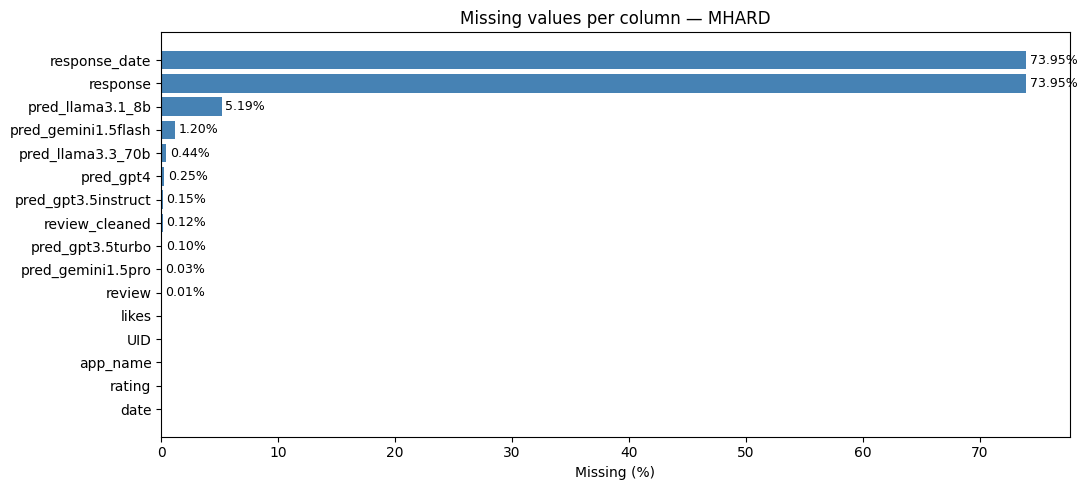

In [10]:
# Visualise missingness so the pattern is obvious at a glance.
# A bar chart makes it easier to see which columns are problematic vs trivial.
plt.figure(figsize=(11, 5))
bars = plt.barh(missing.index, missing["missing_pct"], color="steelblue")
plt.xlabel("Missing (%)")
plt.title("Missing values per column — MHARD")
plt.gca().invert_yaxis()
for bar, pct in zip(bars, missing["missing_pct"]):
    if pct > 0:
        plt.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{pct:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Categorise each column by its role in the pipeline, and decide action.
# This is the cell I can paraphrase into my methodology section.

critical_for_training = ["review", "rating"]
critical_for_eval     = ["pred_gpt3.5instruct", "pred_gpt3.5turbo", "pred_gpt4",
                         "pred_gemini1.5flash", "pred_gemini1.5pro",
                         "pred_llama3.1_8b", "pred_llama3.3_70b"]
metadata_only         = ["UID", "app_name", "date", "likes"]
optional_context      = ["response", "response_date", "review_cleaned"]

print("Role of each column:")
print("-" * 70)
for col in df.columns:
    if col in critical_for_training:
        role = "TRAINING  (must not be null)"
    elif col in critical_for_eval:
        role = "LLM BASELINE  (handle null pairwise)"
    elif col in metadata_only:
        role = "METADATA  (not used for modeling)"
    else:
        role = "OPTIONAL  (EDA or ignore)"
    miss = df[col].isnull().sum()
    print(f"  {col:<22} {role:<38} missing: {miss:,}")
print("-" * 70)

Role of each column:
----------------------------------------------------------------------
  UID                    METADATA  (not used for modeling)      missing: 0
  app_name               METADATA  (not used for modeling)      missing: 0
  rating                 TRAINING  (must not be null)           missing: 0
  date                   METADATA  (not used for modeling)      missing: 0
  review                 TRAINING  (must not be null)           missing: 21
  review_cleaned         OPTIONAL  (EDA or ignore)              missing: 240
  likes                  METADATA  (not used for modeling)      missing: 0
  response_date          OPTIONAL  (EDA or ignore)              missing: 148,609
  response               OPTIONAL  (EDA or ignore)              missing: 148,609
  pred_gpt3.5instruct    LLM BASELINE  (handle null pairwise)   missing: 305
  pred_gpt3.5turbo       LLM BASELINE  (handle null pairwise)   missing: 191
  pred_gpt4              LLM BASELINE  (handle null pairwise)   

In [12]:
# Before we decide the drop strategy, one last check: rows where review exists
# but is only whitespace or an empty string after stripping. Pandas counts those
# as non-null, but they're useless for training.
empty_after_strip = df["review"].fillna("").astype(str).str.strip().eq("").sum()
print(f"Reviews that are null            : {df['review'].isnull().sum():,}")
print(f"Reviews that are empty/whitespace : {empty_after_strip:,}")
print(f"Effective usable reviews          : {len(df) - empty_after_strip:,}")

Reviews that are null            : 21
Reviews that are empty/whitespace : 21
Effective usable reviews          : 200,951


### Step 5: Rating distribution analysis (the class imbalance story)

In [13]:
# Exact counts + percentages for each of the 5 star ratings.
# We build a small summary table so I can paste this directly into the
# dissertation's "Dataset" section of my project
rating_counts = df["rating"].value_counts().sort_index()
rating_pct    = df["rating"].value_counts(normalize=True).sort_index() * 100

rating_summary = pd.DataFrame({
    "count": rating_counts,
    "percentage": rating_pct.round(2)
})
rating_summary.index.name = "rating"

print("=" * 70)
print("5-CLASS RATING DISTRIBUTION (ground truth)")
print("=" * 70)
print(rating_summary)
print("-" * 70)
imbalance_ratio = rating_counts.max() / rating_counts.min()
print(f"Majority class : {rating_counts.idxmax()}-star "
      f"({rating_counts.max():,} reviews)")
print(f"Minority class : {rating_counts.idxmin()}-star "
      f"({rating_counts.min():,} reviews)")
print(f"Imbalance ratio (max / min) : {imbalance_ratio:.2f}x")
print("=" * 70)

5-CLASS RATING DISTRIBUTION (ground truth)
         count  percentage
rating                    
1        34582       17.21
2         8923        4.44
3        11111        5.53
4        25100       12.49
5       121256       60.33
----------------------------------------------------------------------
Majority class : 5-star (121,256 reviews)
Minority class : 2-star (8,923 reviews)
Imbalance ratio (max / min) : 13.59x


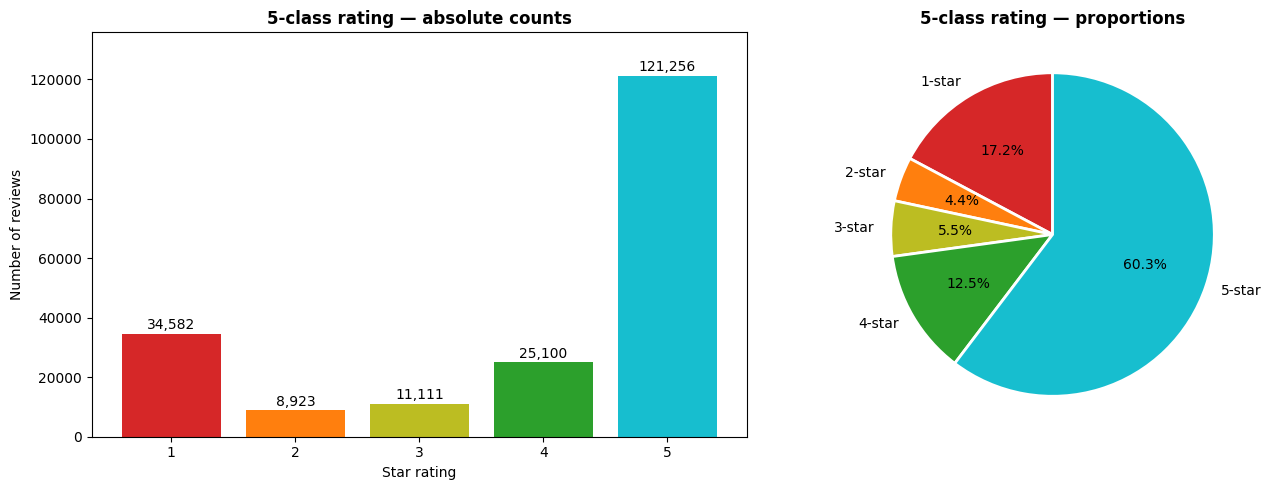

In [14]:
# Dual chart: absolute counts on the left, percentages on the right.
# Same data, two views - the absolute chart shows sample size, the percentage
# chart makes the imbalance visceral.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts
colors_5 = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#17becf"]
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color=colors_5)
axes[0].set_title("5-class rating — absolute counts", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Star rating")
axes[0].set_ylabel("Number of reviews")
for i, v in enumerate(rating_counts.values):
    axes[0].text(i, v + 1500, f"{v:,}", ha="center", fontsize=10)
axes[0].set_ylim(0, rating_counts.max() * 1.12)

# Right: pie for the percentage view
axes[1].pie(
    rating_pct.values,
    labels=[f"{r}-star" for r in rating_pct.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_5,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("5-class rating — proportions", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

3-CLASS SENTIMENT DISTRIBUTION (collapsed)
           count  percentage
rating                      
negative   43505       21.65
neutral    11111        5.53
positive  146356       72.82
----------------------------------------------------------------------
Majority-class baseline (always predict 'positive') accuracy ≈ 72.82%


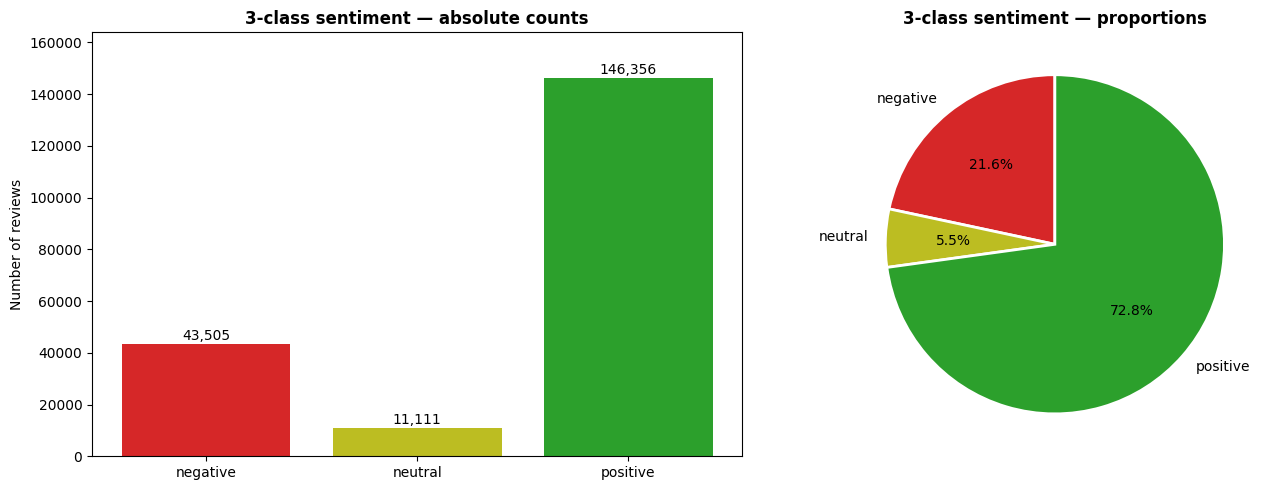

In [15]:

# Now the 3-class collapsed view — this is how Task B will see the world.
# Mapping: 1,2 -> negative   |   3 -> neutral   |   4,5 -> positive
# Important to visualise this BEFORE training because even in 3-class form
# the dataset is still positive-skewed, and that affects how we interpret
# accuracy later (a dumb "always predict positive" baseline already scores ~73%).

def to_3class(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

sentiment_3 = df["rating"].apply(to_3class)
sent_counts = sentiment_3.value_counts().reindex(["negative", "neutral", "positive"])
sent_pct    = (sent_counts / sent_counts.sum() * 100).round(2)

print("=" * 70)
print("3-CLASS SENTIMENT DISTRIBUTION (collapsed)")
print("=" * 70)
print(pd.DataFrame({"count": sent_counts, "percentage": sent_pct}))
print("-" * 70)
print(f"Majority-class baseline (always predict 'positive') accuracy ≈ "
      f"{sent_pct['positive']:.2f}%")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_3 = ["#d62728", "#bcbd22", "#2ca02c"]

axes[0].bar(sent_counts.index, sent_counts.values, color=colors_3)
axes[0].set_title("3-class sentiment — absolute counts", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Number of reviews")
for i, v in enumerate(sent_counts.values):
    axes[0].text(i, v + 1500, f"{v:,}", ha="center", fontsize=10)
axes[0].set_ylim(0, sent_counts.max() * 1.12)

axes[1].pie(
    sent_pct.values, labels=sent_counts.index,
    autopct="%1.1f%%", startangle=90, colors=colors_3,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("3-class sentiment — proportions", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

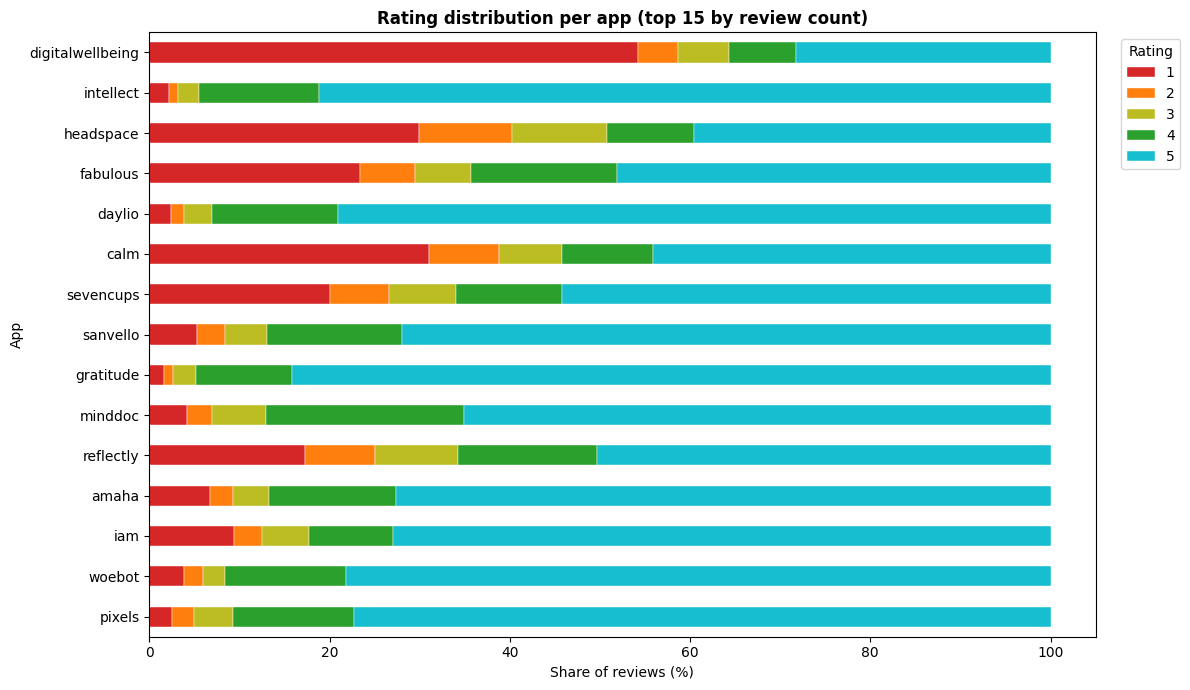

In [16]:
# Per-app rating distribution (top 15 apps by review count) to check whether
# the imbalance is a dataset-wide structural pattern or driven by one or two apps.
# A stacked-percentage bar makes the comparison instant.

top_apps = df["app_name"].value_counts().head(15).index
subset   = df[df["app_name"].isin(top_apps)]

app_rating_pct = (
    subset.groupby("app_name")["rating"]
          .value_counts(normalize=True)
          .unstack()
          .fillna(0)
          .loc[top_apps]          # preserve rank order
          * 100
)

ax = app_rating_pct[[1, 2, 3, 4, 5]].plot(
    kind="barh", stacked=True, figsize=(12, 7),
    color=colors_5, edgecolor="white", linewidth=0.3
)
ax.set_xlabel("Share of reviews (%)")
ax.set_ylabel("App")
ax.set_title("Rating distribution per app (top 15 by review count)",
             fontsize=12, fontweight="bold")
ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# Class-weight preview — if we're going to use weighted cross-entropy during
# training (and we are, given the imbalance), these are the weights we'll pass
# to the loss function. Computing them now serves two purposes:
#   1) Sanity check — minority classes should get ~3-14x more weight
#   2) Documentation — these numbers go into the methodology section
from sklearn.utils.class_weight import compute_class_weight

# 5-class weights (labels will be rating-1 so they're 0..4)
y5 = (df["rating"] - 1).values
weights_5 = compute_class_weight(class_weight="balanced",
                                 classes=np.array([0, 1, 2, 3, 4]),
                                 y=y5)

# 3-class weights (negative=0, neutral=1, positive=2)
map3 = {1: 0, 2: 0, 3: 1, 4: 2, 5: 2}
y3 = df["rating"].map(map3).values
weights_3 = compute_class_weight(class_weight="balanced",
                                 classes=np.array([0, 1, 2]),
                                 y=y3)

print("=" * 70)
print("CLASS WEIGHTS (balanced inverse-frequency)")
print("=" * 70)
print("5-class:")
for cls, w in zip([1, 2, 3, 4, 5], weights_5):
    print(f"  {cls}-star  ->  weight = {w:.4f}")
print()
print("3-class:")
for cls, w in zip(["negative", "neutral", "positive"], weights_3):
    print(f"  {cls:<9} ->  weight = {w:.4f}")
print("=" * 70)

CLASS WEIGHTS (balanced inverse-frequency)
5-class:
  1-star  ->  weight = 1.1623
  2-star  ->  weight = 4.5046
  3-star  ->  weight = 3.6175
  4-star  ->  weight = 1.6014
  5-star  ->  weight = 0.3315

3-class:
  negative  ->  weight = 1.5398
  neutral   ->  weight = 6.0292
  positive  ->  weight = 0.4577


### Step 6: Review length analysis and the max_length decision

In [18]:
# Compute word count for the RAW review (since that's what we'll tokenize),
# and character count as a secondary view. We handle the 21 nulls and the
# whitespace-only cases cleanly with fillna("") + strip() so length = 0 for
# those rows rather than NaN.

reviews = df["review"].fillna("").astype(str).str.strip()
word_counts = reviews.str.split().str.len()
char_counts = reviews.str.len()

length_stats = pd.DataFrame({
    "metric": ["mean", "std", "min", "25%", "50% (median)", "75%", "90%", "95%", "99%", "max"],
    "word_count": [
        word_counts.mean(), word_counts.std(), word_counts.min(),
        word_counts.quantile(0.25), word_counts.quantile(0.50),
        word_counts.quantile(0.75), word_counts.quantile(0.90),
        word_counts.quantile(0.95), word_counts.quantile(0.99),
        word_counts.max()
    ],
    "char_count": [
        char_counts.mean(), char_counts.std(), char_counts.min(),
        char_counts.quantile(0.25), char_counts.quantile(0.50),
        char_counts.quantile(0.75), char_counts.quantile(0.90),
        char_counts.quantile(0.95), char_counts.quantile(0.99),
        char_counts.max()
    ],
}).round(1)

print("=" * 70)
print("REVIEW LENGTH STATISTICS (raw review column)")
print("=" * 70)
print(length_stats.to_string(index=False))
print("=" * 70)

REVIEW LENGTH STATISTICS (raw review column)
      metric  word_count  char_count
        mean        31.2       165.1
         std        26.0       138.7
         min         0.0         0.0
         25%        11.0        59.0
50% (median)        23.0       123.0
         75%        44.0       231.0
         90%        72.0       383.0
         95%        87.0       474.0
         99%        98.0       499.0
         max       674.0      3649.0


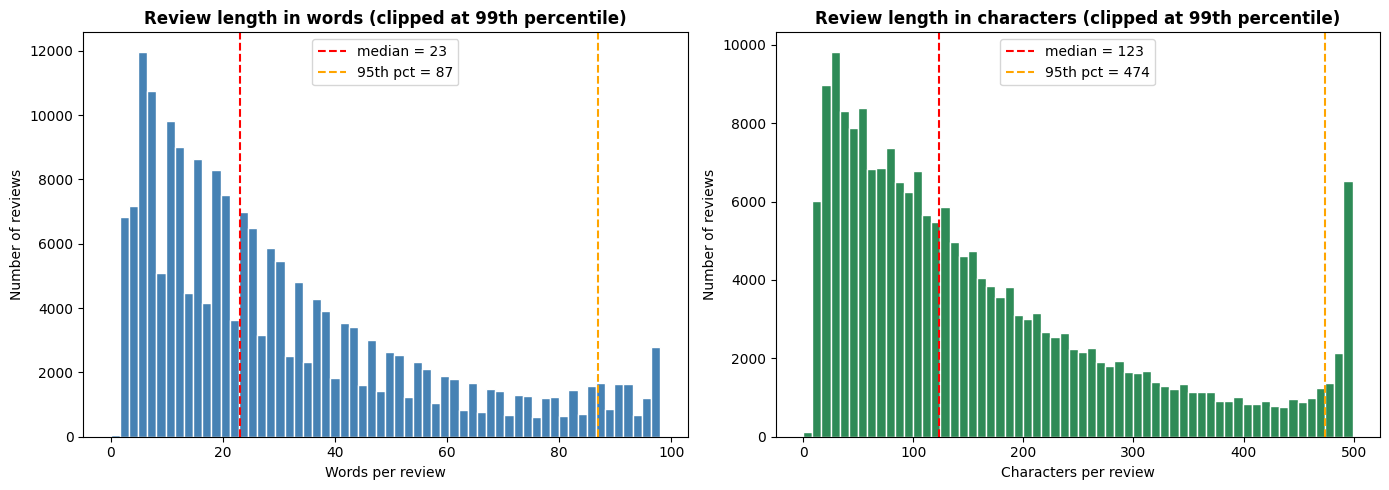

In [19]:
# Distribution plots. We clip at the 99th percentile for the x-axis so the
# long right tail (a handful of 500+ word reviews) doesn't squash the bulk
# of the distribution into an unreadable sliver.

p99_words = int(word_counts.quantile(0.99))
p99_chars = int(char_counts.quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(word_counts.clip(upper=p99_words), bins=60,
             color="steelblue", edgecolor="white")
axes[0].axvline(word_counts.median(), color="red", linestyle="--",
                label=f"median = {int(word_counts.median())}")
axes[0].axvline(word_counts.quantile(0.95), color="orange", linestyle="--",
                label=f"95th pct = {int(word_counts.quantile(0.95))}")
axes[0].set_title("Review length in words (clipped at 99th percentile)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Words per review")
axes[0].set_ylabel("Number of reviews")
axes[0].legend()

axes[1].hist(char_counts.clip(upper=p99_chars), bins=60,
             color="seagreen", edgecolor="white")
axes[1].axvline(char_counts.median(), color="red", linestyle="--",
                label=f"median = {int(char_counts.median())}")
axes[1].axvline(char_counts.quantile(0.95), color="orange", linestyle="--",
                label=f"95th pct = {int(char_counts.quantile(0.95))}")
axes[1].set_title("Review length in characters (clipped at 99th percentile)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Characters per review")
axes[1].set_ylabel("Number of reviews")
axes[1].legend()

plt.tight_layout()
plt.show()

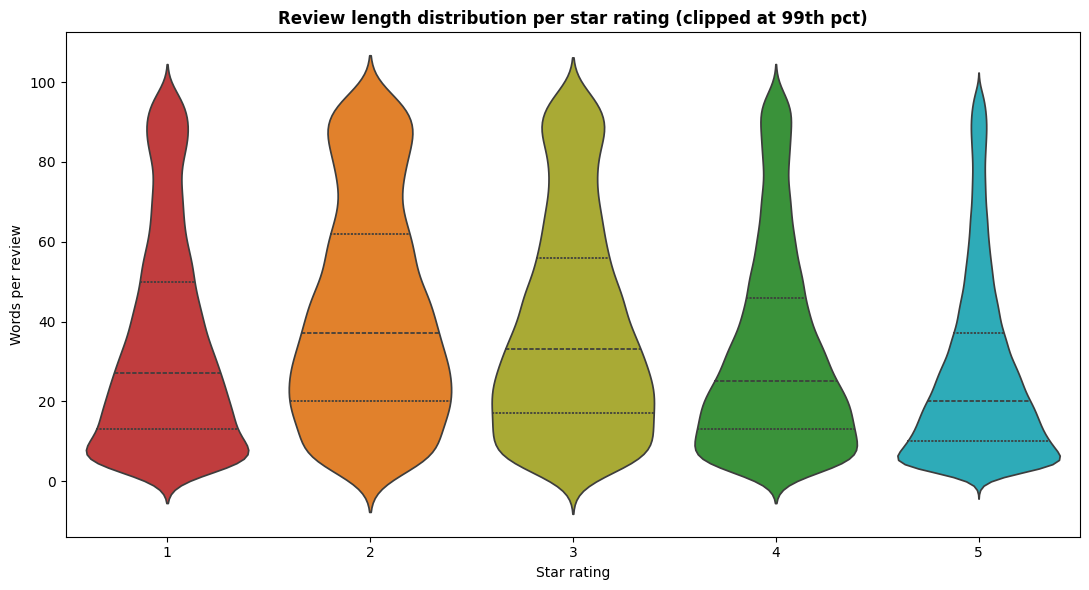


Median word count per rating:
        median_words
rating              
1               28.0
2               38.0
3               33.0
4               26.0
5               20.0


In [20]:
# Word count by rating — do 1-star rants and 5-star raves have different lengths?
# This matters because if there's a strong correlation between length and rating,
# the model may learn a shortcut (long review = negative) and we want to be
# aware of it. A violin plot shows the full distribution per class, not just
# mean/median.

df_len = pd.DataFrame({"rating": df["rating"], "word_count": word_counts})

plt.figure(figsize=(11, 6))
sns.violinplot(data=df_len[df_len["word_count"] <= p99_words],
               x="rating", y="word_count",
               inner="quartile", palette=colors_5)
plt.title("Review length distribution per star rating (clipped at 99th pct)",
          fontsize=12, fontweight="bold")
plt.xlabel("Star rating")
plt.ylabel("Words per review")
plt.tight_layout()
plt.show()

print("\nMedian word count per rating:")
print(df_len.groupby("rating")["word_count"].median().to_frame("median_words"))

In [21]:
# Now the actual engineering decision: what max_length should we pass to the
# DistilBERT tokenizer?
#
# DistilBERT supports up to 512 tokens, but every extra token costs compute
# QUADRATICALLY in the attention layer (well, technically, but in practice
# it's a big linear cost too during training). Since my whole thesis is
# about reducing carbon cost, we should pick the SMALLEST max_length that
# still covers the vast majority of real reviews without truncating them.
#
# Rule of thumb: 1 English word ~ 1.3 WordPiece tokens (subwords). So:
#   - 95th percentile words * 1.3 gives the token count that covers 95% of reviews
#   - 99th percentile words * 1.3 covers 99%
#
# We compute both and recommend a power-of-2 max_length (128 or 256) that sits
# comfortably above the 95th percentile target.

p95_words = word_counts.quantile(0.95)
p99_words_val = word_counts.quantile(0.99)

est_tokens_p95 = int(p95_words * 1.3)
est_tokens_p99 = int(p99_words_val * 1.3)

print("=" * 70)
print("max_length DECISION")
print("=" * 70)
print(f"95th-percentile review length : {int(p95_words)} words "
      f"~ {est_tokens_p95} WordPiece tokens")
print(f"99th-percentile review length : {int(p99_words_val)} words "
      f"~ {est_tokens_p99} WordPiece tokens")
print()
print("Candidate max_length values (powers of 2):")
for ml in [64, 128, 256, 512]:
    if ml < est_tokens_p95:
        verdict = f"TOO SHORT  (truncates >5% of reviews)"
    elif ml < est_tokens_p99:
        verdict = f"OK         (covers 95%+, truncates ~1-5%)"
    else:
        verdict = f"SAFE       (covers 99%+, near-zero truncation)"
    print(f"  max_length = {ml:<4} -> {verdict}")
print("=" * 70)

max_length DECISION
95th-percentile review length : 87 words ~ 113 WordPiece tokens
99th-percentile review length : 98 words ~ 127 WordPiece tokens

Candidate max_length values (powers of 2):
  max_length = 64   -> TOO SHORT  (truncates >5% of reviews)
  max_length = 128  -> SAFE       (covers 99%+, near-zero truncation)
  max_length = 256  -> SAFE       (covers 99%+, near-zero truncation)
  max_length = 512  -> SAFE       (covers 99%+, near-zero truncation)


In [22]:
# Empirical verification: actually tokenize a sample of 2,000 reviews and
# measure the real subword-token counts. The 1.3 multiplier above is a rule
# of thumb; let's confirm with real tokenizer output before committing to
# a max_length value.

from transformers import DistilBertTokenizerFast
tok = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

sample = reviews.sample(n=2000, random_state=RANDOM_SEED).tolist()
token_lens = [len(tok.encode(s, add_special_tokens=True)) for s in sample]
token_lens = pd.Series(token_lens)

print("Actual DistilBERT token lengths on a 2,000-review sample:")
print(f"  mean   : {token_lens.mean():.1f}")
print(f"  median : {token_lens.median():.0f}")
print(f"  95th % : {token_lens.quantile(0.95):.0f}")
print(f"  99th % : {token_lens.quantile(0.99):.0f}")
print(f"  max    : {token_lens.max()}")
print()

# How much of the sample would each candidate max_length truncate?
for ml in [64, 128, 256, 512]:
    pct_truncated = (token_lens > ml).mean() * 100
    print(f"  max_length = {ml:<4} would truncate {pct_truncated:5.2f}% of reviews")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Actual DistilBERT token lengths on a 2,000-review sample:
  mean   : 39.1
  median : 30
  95th % : 107
  99th % : 124
  max    : 165

  max_length = 64   would truncate 18.05% of reviews
  max_length = 128  would truncate  0.55% of reviews
  max_length = 256  would truncate  0.00% of reviews
  max_length = 512  would truncate  0.00% of reviews


### Step 7: Data cleaning implementation

In [23]:
# Lock in the tokenization parameter based on the empirical measurement.
# 128 covers 99.45% of reviews without truncation while minimising training
# compute and inference time (both directly tied to carbon emissions).
MAX_LENGTH = 128
print(f"MAX_LENGTH = {MAX_LENGTH}  (locks in Step 6 empirical finding: "
      f"truncates only 0.55% of reviews, median review = 30 tokens)")

# Work on a copy. If anything goes wrong, the original df is still intact
# and we don't have to re-read 80 MB from Drive.
df_clean = df.copy()
print(f"\nStarting shape : {df_clean.shape}")

MAX_LENGTH = 128  (locks in Step 6 empirical finding: truncates only 0.55% of reviews, median review = 30 tokens)

Starting shape : (200972, 16)


In [24]:
# Text normalization function.
# Philosophy: do as LITTLE as possible. DistilBERT's tokenizer already handles
# casing, punctuation, contractions, and subwords. Classical NLP cleaning
# (stopwords, stemming, lowercasing) would DESTROY signal. All we do is:
#   1) strip leading/trailing whitespace
#   2) collapse URLs (rare in app reviews but they tokenize into long junk sequences)
#   3) collapse character repetitions ("sooooo goooood" -> "soo goood") because
#      long repeats produce unnecessary subword tokens with no added meaning
#   4) collapse runs of whitespace to a single space

import re

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
REPEATED_CHAR_PATTERN = re.compile(r"(.)\1{2,}")     # any char repeated 3+ times
MULTI_WHITESPACE_PATTERN = re.compile(r"\s+")

def normalize_review(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = URL_PATTERN.sub(" ", text)                 # strip URLs
    text = REPEATED_CHAR_PATTERN.sub(r"\1\1", text)   # sooo -> soo
    text = MULTI_WHITESPACE_PATTERN.sub(" ", text)    # collapse whitespace
    return text.strip()

# Demo on a few real examples so we can see exactly what the normalizer touches.
demo_texts = [
    "   I LOVE this app sooooooo much!!!!   ",
    "Best app ever go check it out at https://example.com/download now",
    "i cant believe                 this worked so well",
    "yesssssssssss finally a decent mental health tracker",
    "The app is fine.",    # already clean — should be unchanged
]

print("Normalization demo (BEFORE -> AFTER):")
print("-" * 70)
for t in demo_texts:
    print(f"BEFORE: {repr(t)}")
    print(f"AFTER : {repr(normalize_review(t))}")
    print()

Normalization demo (BEFORE -> AFTER):
----------------------------------------------------------------------
BEFORE: '   I LOVE this app sooooooo much!!!!   '
AFTER : 'I LOVE this app soo much!!'

BEFORE: 'Best app ever go check it out at https://example.com/download now'
AFTER : 'Best app ever go check it out at now'

BEFORE: 'i cant believe                 this worked so well'
AFTER : 'i cant believe this worked so well'

BEFORE: 'yesssssssssss finally a decent mental health tracker'
AFTER : 'yess finally a decent mental health tracker'

BEFORE: 'The app is fine.'
AFTER : 'The app is fine.'



In [25]:
# Apply the cleaning pipeline, in order, tracking how many rows each step removes.
# Each check is logged so I have the exact cleaning audit trail for my
# dissertation's "Data preprocessing" paragraph.

initial_rows = len(df_clean)
print("=" * 70)
print("CLEANING PIPELINE")
print("=" * 70)
print(f"Initial rows: {initial_rows:,}")

# 1) Drop rows where 'review' is null
df_clean = df_clean[df_clean["review"].notna()].copy()
print(f"After dropping null reviews       : {len(df_clean):,}  "
      f"(-{initial_rows - len(df_clean):,})")

# 2) Normalize the review text
df_clean["review"] = df_clean["review"].apply(normalize_review)

# 3) Drop rows whose normalized review is empty (could happen if it was only
#    whitespace or only a URL)
before = len(df_clean)
df_clean = df_clean[df_clean["review"].str.len() > 0].copy()
print(f"After dropping empty-after-norm   : {len(df_clean):,}  "
      f"(-{before - len(df_clean):,})")

# 4) Drop rows with fewer than 3 words — too short to carry useful signal
before = len(df_clean)
word_counts_after = df_clean["review"].str.split().str.len()
df_clean = df_clean[word_counts_after >= 3].copy()
print(f"After dropping reviews < 3 words  : {len(df_clean):,}  "
      f"(-{before - len(df_clean):,})")

# 5) Reset index so row numbers are contiguous after all the dropping
df_clean = df_clean.reset_index(drop=True)

total_removed = initial_rows - len(df_clean)
print("-" * 70)
print(f"Total rows removed                : {total_removed:,} "
      f"({total_removed / initial_rows * 100:.2f}%)")
print(f"Final rows                        : {len(df_clean):,}")
print("=" * 70)

CLEANING PIPELINE
Initial rows: 200,972
After dropping null reviews       : 200,951  (-21)
After dropping empty-after-norm   : 200,951  (-0)
After dropping reviews < 3 words  : 200,812  (-139)
----------------------------------------------------------------------
Total rows removed                : 160 (0.08%)
Final rows                        : 200,812


In [26]:
# Drop the columns we will not use.
# 'response' and 'response_date' are ~74% missing and aren't needed for either
# training or the LLM-baseline comparison.
# 'review_cleaned' we keep for now — we use it for the word-cloud EDA in the
# next step, then drop it right before tokenization.

cols_to_drop = ["response", "response_date"]
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped columns : {cols_to_drop}")
print(f"Remaining columns ({len(df_clean.columns)}):")
for c in df_clean.columns:
    miss = df_clean[c].isnull().sum()
    print(f"  - {c:<22} missing: {miss:,}")

Dropped columns : ['response', 'response_date']
Remaining columns (14):
  - UID                    missing: 0
  - app_name               missing: 0
  - rating                 missing: 0
  - date                   missing: 0
  - review                 missing: 0
  - review_cleaned         missing: 211
  - likes                  missing: 0
  - pred_gpt3.5instruct    missing: 304
  - pred_gpt3.5turbo       missing: 191
  - pred_gpt4              missing: 496
  - pred_gemini1.5flash    missing: 2,396
  - pred_gemini1.5pro      missing: 54
  - pred_llama3.1_8b       missing: 10,375
  - pred_llama3.3_70b      missing: 872


Rating distribution before vs after cleaning:
        before_%  after_%  delta
rating                          
1          17.21    17.21   0.01
2           4.44     4.44   0.00
3           5.53     5.53   0.00
4          12.49    12.49   0.00
5          60.33    60.32  -0.01


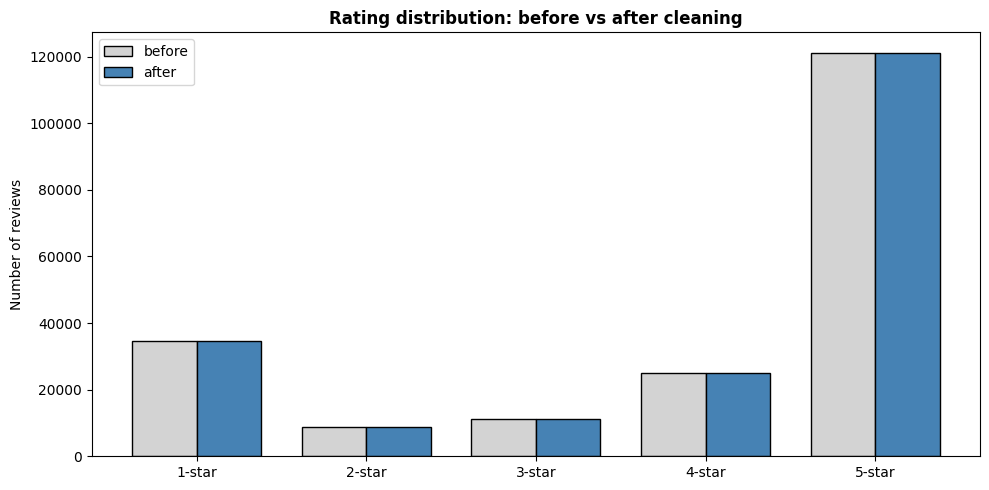

In [27]:
# Sanity check: confirm the rating distribution is essentially unchanged after
# cleaning. If we accidentally filtered out an entire class or hugely shifted
# the proportions, we need to know now before training.

before_dist = df["rating"].value_counts(normalize=True).sort_index() * 100
after_dist  = df_clean["rating"].value_counts(normalize=True).sort_index() * 100

comparison = pd.DataFrame({
    "before_%": before_dist.round(2),
    "after_%":  after_dist.round(2),
    "delta":    (after_dist - before_dist).round(2)
})
comparison.index.name = "rating"

print("Rating distribution before vs after cleaning:")
print(comparison)

# Also visualise the before/after counts
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(5)
width = 0.38
ax.bar(x - width/2, df["rating"].value_counts().sort_index().values,
       width, label="before", color="lightgray", edgecolor="black")
ax.bar(x + width/2, df_clean["rating"].value_counts().sort_index().values,
       width, label="after", color="steelblue", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels([f"{r}-star" for r in [1, 2, 3, 4, 5]])
ax.set_ylabel("Number of reviews")
ax.set_title("Rating distribution: before vs after cleaning", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### Step 8: Word clouds per rating + LLM prediction agreement preview

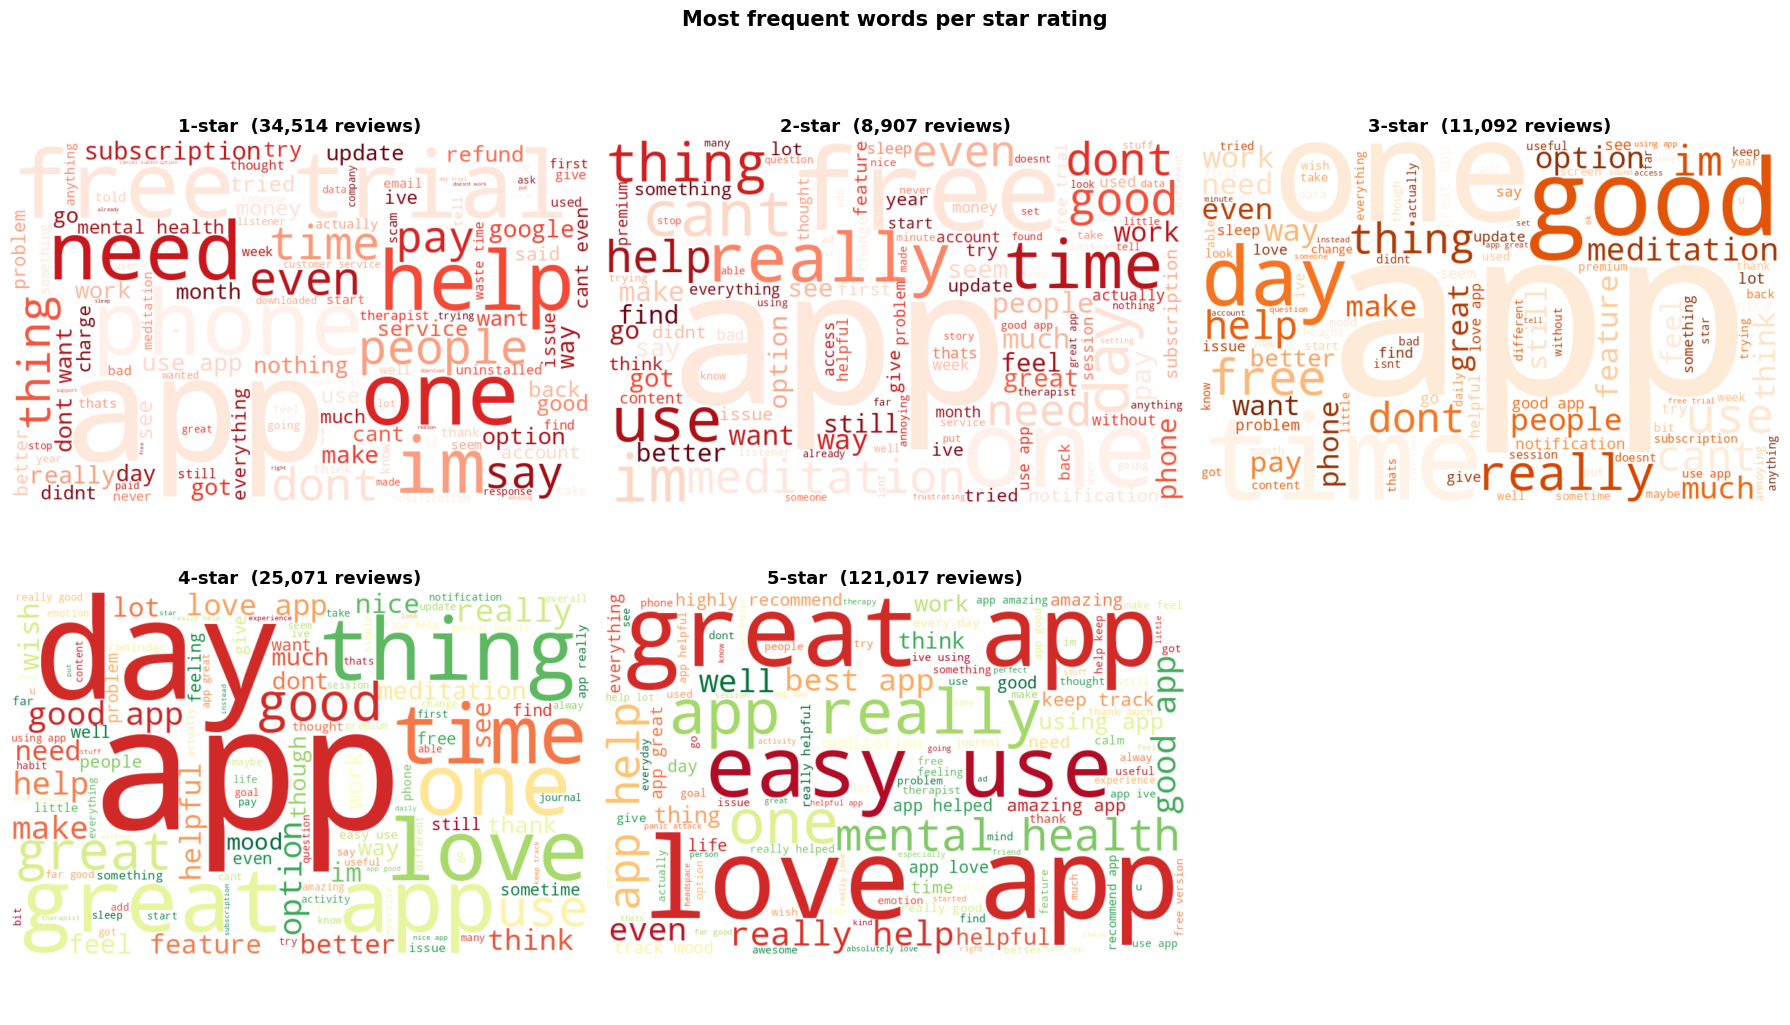

In [28]:
# Word cloud per star rating, built from the already-cleaned 'review_cleaned'
# column (stopwords + punctuation removed). This is the one place where we
# WANT the pre-cleaned column — word clouds are dominated by 'the', 'I',
# 'and' if you feed them raw text. After this cell, review_cleaned's job
# is done and we'll drop it before building the HF Dataset.

from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, rating in enumerate([1, 2, 3, 4, 5]):
    subset = df_clean[df_clean["rating"] == rating]["review_cleaned"].dropna()
    text = " ".join(subset.astype(str).tolist())

    if len(text) == 0:
        axes[i].axis("off")
        continue

    wc = WordCloud(
        width=800, height=500,
        background_color="white",
        max_words=120,
        colormap="RdYlGn" if rating >= 4 else ("Reds" if rating <= 2 else "Oranges"),
        random_state=RANDOM_SEED,
    ).generate(text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"{rating}-star  ({len(subset):,} reviews)",
                      fontsize=13, fontweight="bold")
    axes[i].axis("off")

# Hide the 6th (unused) subplot
axes[5].axis("off")
plt.suptitle("Most frequent words per star rating",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Top 15 distinctive words per rating — a more quantitative companion to the
# word clouds. Word clouds show frequency, but frequency alone is misleading
# because 'app' is the top word in every class. We want to know which words
# are DISPROPORTIONATELY common in each class relative to the whole corpus.
#
# We use log-odds: for each word, compare its frequency within this rating
# class to its frequency in all other classes. Words with high positive
# log-odds are distinctive to this class.

from collections import Counter

def top_distinctive_words(df_in, rating, n=15, min_count=50):
    in_class   = " ".join(df_in[df_in["rating"] == rating]["review_cleaned"]
                           .dropna().astype(str)).split()
    out_class  = " ".join(df_in[df_in["rating"] != rating]["review_cleaned"]
                           .dropna().astype(str)).split()
    cnt_in   = Counter(in_class)
    cnt_out  = Counter(out_class)

    total_in  = sum(cnt_in.values())
    total_out = sum(cnt_out.values())

    scores = {}
    for word, c_in in cnt_in.items():
        if c_in < min_count:      # ignore rare words to avoid noise
            continue
        c_out = cnt_out.get(word, 0)
        # Add-1 smoothing to avoid log(0)
        p_in  = (c_in + 1)  / (total_in  + 1)
        p_out = (c_out + 1) / (total_out + 1)
        scores[word] = np.log(p_in / p_out)

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]

print("=" * 70)
print("TOP 15 DISTINCTIVE WORDS PER RATING  (log-odds vs all other ratings)")
print("=" * 70)
for rating in [1, 2, 3, 4, 5]:
    words = top_distinctive_words(df_clean, rating, n=15)
    print(f"\n{rating}-star:")
    print("  " + ", ".join(f"{w} ({s:.2f})" for w, s in words))
print("=" * 70)

TOP 15 DISTINCTIVE WORDS PER RATING  (log-odds vs all other ratings)

1-star:
  bloatware (5.16), spyware (5.14), thief (4.70), spy (4.64), fraud (4.59), malware (4.11), spying (4.09), scam (4.00), refused (3.93), garbage (3.91), disgusting (3.84), consent (3.77), pathetic (3.62), dispute (3.60), scammer (3.58)

2-star:
  disappointing (1.52), frustrating (1.49), seemed (1.47), buggy (1.45), disappointed (1.34), shame (1.33), unfortunately (1.30), wall (1.29), locked (1.28), sorry (1.28), poor (1.26), paywall (1.25), measurement (1.23), reinstall (1.22), reinstalled (1.21)

3-star:
  alright (1.84), glitchy (1.61), scroll (1.43), ok (1.41), buggy (1.38), measurement (1.35), offline (1.35), okay (1.35), sadly (1.31), frustrating (1.25), decent (1.24), unfortunately (1.20), however (1.20), freeze (1.20), perhaps (1.19)

4-star:
  downside (2.05), four (1.53), itd (1.46), otherwise (1.41), wish (1.31), eg (1.25), slightly (1.22), minor (1.16), sometimes (1.15), repetitive (1.13), missing 

In [30]:
# Now the LLM baseline preview — the single most important EDA check for
# my thesis question. For each of the 7 LLMs, how often does its prediction
# agree exactly with the ground-truth rating? This is accuracy computed on
# the FULL dataset (before our train/test split), so it's a ceiling estimate
# of what DistilBERT needs to beat / match to be competitive.

llm_cols = [
    "pred_gpt3.5instruct",
    "pred_gpt3.5turbo",
    "pred_gpt4",
    "pred_gemini1.5flash",
    "pred_gemini1.5pro",
    "pred_llama3.1_8b",
    "pred_llama3.3_70b",
]

llm_preview = []
for col in llm_cols:
    mask = df_clean[col].notna()
    n    = mask.sum()
    acc  = (df_clean.loc[mask, col] == df_clean.loc[mask, "rating"]).mean()
    mae  = (df_clean.loc[mask, col] - df_clean.loc[mask, "rating"]).abs().mean()
    llm_preview.append({
        "LLM": col.replace("pred_", ""),
        "n_evaluated": n,
        "missing": len(df_clean) - n,
        "accuracy": round(acc, 4),
        "MAE": round(mae, 3),
    })

llm_preview_df = pd.DataFrame(llm_preview).sort_values("accuracy", ascending=False)
print("=" * 70)
print("LLM BASELINE PREVIEW (full cleaned dataset, pairwise-available)")
print("=" * 70)
print(llm_preview_df.to_string(index=False))
print("=" * 70)
print("\nInterpretation:")
print("  - accuracy: fraction of reviews where LLM == ground truth (exact match)")
print("  - MAE     : average |predicted - true| stars; 0 is perfect, higher = worse")
print("  - These are the numbers DistilBERT needs to match or approach.")

LLM BASELINE PREVIEW (full cleaned dataset, pairwise-available)
           LLM  n_evaluated  missing  accuracy   MAE
          gpt4       200316      496    0.7518 0.307
  llama3.3_70b       199940      872    0.7452 0.326
  gemini1.5pro       200758       54    0.7415 0.321
gpt3.5instruct       200508      304    0.6945 0.370
   gpt3.5turbo       200621      191    0.6700 0.397
gemini1.5flash       198416     2396    0.6163 0.502
   llama3.1_8b       190437    10375    0.6135 0.618

Interpretation:
  - accuracy: fraction of reviews where LLM == ground truth (exact match)
  - MAE     : average |predicted - true| stars; 0 is perfect, higher = worse
  - These are the numbers DistilBERT needs to match or approach.


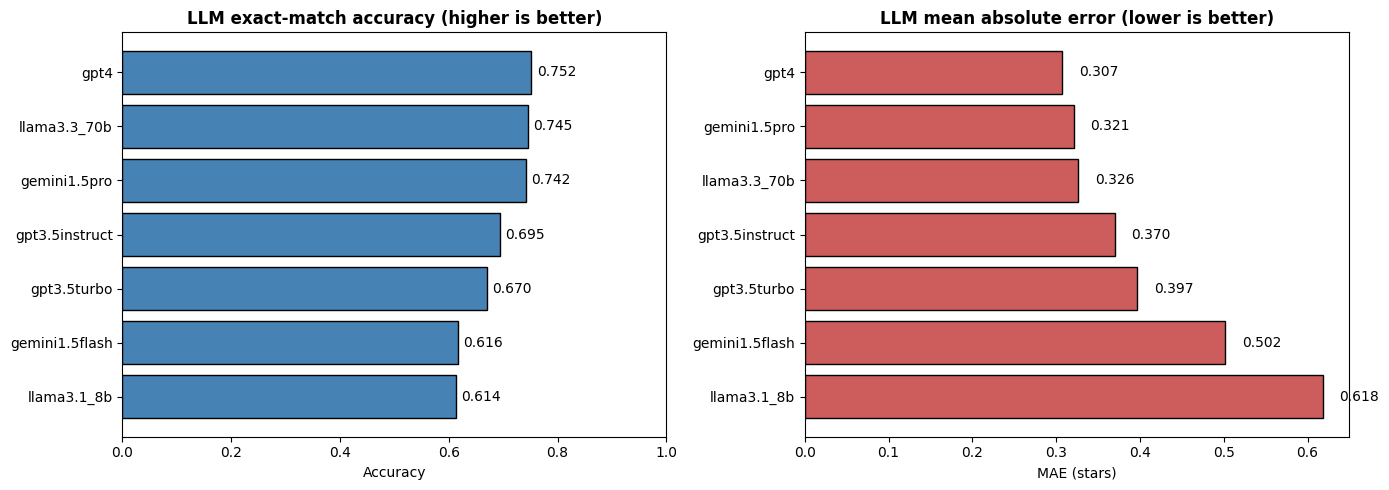

In [31]:
# Visualise the LLM preview as a chart — two side-by-side bars, accuracy
# and MAE, sorted consistently. MAE is plotted with an inverted y-axis
# indicator so 'higher is better' is visually consistent across both charts.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

llm_sorted = llm_preview_df.sort_values("accuracy")
bars_a = axes[0].barh(llm_sorted["LLM"], llm_sorted["accuracy"],
                      color="steelblue", edgecolor="black")
axes[0].set_title("LLM exact-match accuracy (higher is better)", fontweight="bold")
axes[0].set_xlabel("Accuracy")
axes[0].set_xlim(0, 1)
for b, v in zip(bars_a, llm_sorted["accuracy"]):
    axes[0].text(v + 0.01, b.get_y() + b.get_height()/2,
                 f"{v:.3f}", va="center", fontsize=10)

llm_sorted_mae = llm_preview_df.sort_values("MAE", ascending=False)
bars_m = axes[1].barh(llm_sorted_mae["LLM"], llm_sorted_mae["MAE"],
                      color="indianred", edgecolor="black")
axes[1].set_title("LLM mean absolute error (lower is better)", fontweight="bold")
axes[1].set_xlabel("MAE (stars)")
for b, v in zip(bars_m, llm_sorted_mae["MAE"]):
    axes[1].text(v + 0.02, b.get_y() + b.get_height()/2,
                 f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

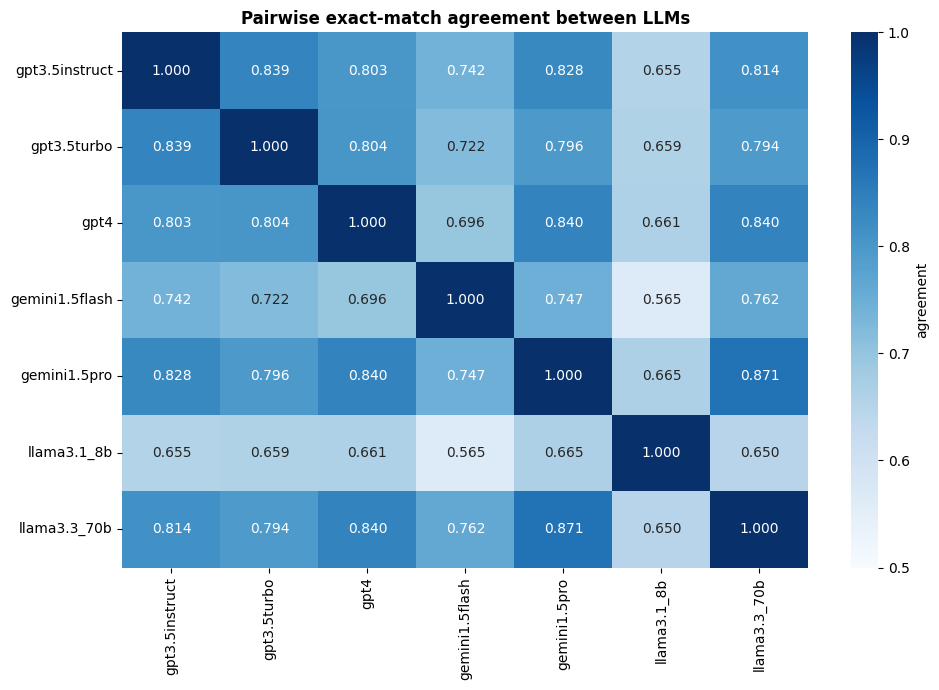

In [32]:
# Pairwise agreement between the LLMs themselves — do they agree with each
# other more than they agree with ground truth? If yes, that's an interesting
# finding on its own (the LLMs share systematic biases). We compute exact-match
# agreement on the subset of rows where BOTH models have a prediction.

agreement_matrix = pd.DataFrame(index=llm_cols, columns=llm_cols, dtype=float)
for a in llm_cols:
    for b in llm_cols:
        mask = df_clean[a].notna() & df_clean[b].notna()
        agreement_matrix.loc[a, b] = (df_clean.loc[mask, a] == df_clean.loc[mask, b]).mean()

# Rename for readability
short_names = [c.replace("pred_", "") for c in llm_cols]
agreement_matrix.index = short_names
agreement_matrix.columns = short_names

plt.figure(figsize=(10, 7))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt=".3f",
            cmap="Blues", vmin=0.5, vmax=1.0, cbar_kws={"label": "agreement"})
plt.title("Pairwise exact-match agreement between LLMs", fontweight="bold")
plt.tight_layout()
plt.show()

Strong numbers and actually better than I predicted lol. GPT-4 at 75.2% / MAE 0.307 is the bar to beat. Gemini 1.5 Pro and LLaMA 3.3 70B are statistically tied with GPT-4 (0.742–0.752, ~1pp spread). The two smaller models (Gemini 1.5 Flash, LLaMA 3.1 8B) sit at ~0.61. That spread is exactly the story I want: frontier LLMs cluster at ~75%, and my DistilBERT target is to land somewhere in that top cluster at a fraction of the carbon cost.

### Step 9: Label encoding for both tasks + matching remapping of LLM predictions

In [33]:
# TASK A: 5-class ordinal label
# Ratings are 1..5 in the raw data, but PyTorch/HuggingFace classification heads
# expect 0-indexed labels (0..num_labels-1). So we subtract 1.
# Mapping:   rating 1 -> label 0   (1-star)
#            rating 2 -> label 1   (2-star)
#            rating 3 -> label 2   (3-star)
#            rating 4 -> label 3   (4-star)
#            rating 5 -> label 4   (5-star)

df_clean["label_5class"] = df_clean["rating"] - 1

# Keep a mapping dict for later — I'll need this to decode predictions back
# into human-readable star ratings (for the confusion matrix, for inference
# demos, and for the saved model config's id2label field).
label_mapping_5class = {0: "1-star", 1: "2-star", 2: "3-star", 3: "4-star", 4: "5-star"}
id2label_5 = label_mapping_5class
label2id_5 = {v: k for k, v in id2label_5.items()}

print("5-class label encoding:")
print("-" * 50)
for k, v in label_mapping_5class.items():
    n = (df_clean["label_5class"] == k).sum()
    print(f"  rating {k+1}  ->  label {k}  ->  '{v}'   ({n:,} samples)")
print()

5-class label encoding:
--------------------------------------------------
  rating 1  ->  label 0  ->  '1-star'   (34,569 samples)
  rating 2  ->  label 1  ->  '2-star'   (8,918 samples)
  rating 3  ->  label 2  ->  '3-star'   (11,104 samples)
  rating 4  ->  label 3  ->  '4-star'   (25,085 samples)
  rating 5  ->  label 4  ->  '5-star'   (121,136 samples)



In [34]:
# TASK B: 3-class sentiment label
# Mapping:   rating 1,2  -> label 0  (negative)
#            rating 3    -> label 1  (neutral)
#            rating 4,5  -> label 2  (positive)
#
# The rationale is the one we established in Step 5: this is the collapsed
# sentiment view for Task B. The threshold at rating 3 = neutral is the
# standard convention in star-rating sentiment work and matches what Wang
# et al. and similar review-classification papers use.

def to_3class_label(rating):
    if rating <= 2:
        return 0       # negative
    elif rating == 3:
        return 1       # neutral
    else:
        return 2       # positive

df_clean["label_3class"] = df_clean["rating"].apply(to_3class_label)

label_mapping_3class = {0: "negative", 1: "neutral", 2: "positive"}
id2label_3 = label_mapping_3class
label2id_3 = {v: k for k, v in id2label_3.items()}

print("3-class label encoding:")
print("-" * 50)
for k, v in label_mapping_3class.items():
    n = (df_clean["label_3class"] == k).sum()
    pct = n / len(df_clean) * 100
    print(f"  label {k}  ->  '{v}'   ({n:,} samples, {pct:.2f}%)")
print()

3-class label encoding:
--------------------------------------------------
  label 0  ->  'negative'   (43,487 samples, 21.66%)
  label 1  ->  'neutral'   (11,104 samples, 5.53%)
  label 2  ->  'positive'   (146,221 samples, 72.81%)



In [35]:
# Matching 3-class remapping for the LLM prediction columns.
#
# WHY THIS MATTERS: when we evaluate the 3-class DistilBERT head, we need
# comparable 3-class predictions from every LLM. A GPT-4 prediction of "4"
# has to become "positive" so we compare like with like. We create new
# columns and leave the original 1-5 predictions untouched for the 5-class
# comparison.
#
# NaN handling: we use a vectorised apply with a safe function so missing
# LLM predictions stay NaN in the new columns (we'll handle them
# pairwise-available at evaluation time, same as before).

def rating_to_3class(r):
    if pd.isna(r):
        return np.nan
    r = int(r)
    if r <= 2:  return 0
    if r == 3:  return 1
    return 2

llm_cols = [
    "pred_gpt3.5instruct", "pred_gpt3.5turbo", "pred_gpt4",
    "pred_gemini1.5flash", "pred_gemini1.5pro",
    "pred_llama3.1_8b", "pred_llama3.3_70b",
]

for col in llm_cols:
    new_col = col + "_3class"
    df_clean[new_col] = df_clean[col].apply(rating_to_3class)

print("Remapped LLM predictions to 3-class sentiment labels.")
print("New columns added:")
for col in llm_cols:
    new_col = col + "_3class"
    n_missing = df_clean[new_col].isna().sum()
    print(f"  {new_col:<40}  missing: {n_missing:,}")

Remapped LLM predictions to 3-class sentiment labels.
New columns added:
  pred_gpt3.5instruct_3class                missing: 304
  pred_gpt3.5turbo_3class                   missing: 191
  pred_gpt4_3class                          missing: 496
  pred_gemini1.5flash_3class                missing: 2,396
  pred_gemini1.5pro_3class                  missing: 54
  pred_llama3.1_8b_3class                   missing: 10,375
  pred_llama3.3_70b_3class                  missing: 872


In [36]:
# Sanity check — the new label columns should be internally consistent:
# label_3class must agree with label_5class after collapsing. I assert this
# programmatically so if something is wrong it fails LOUDLY rather than
# silently contaminating training.

# Verify: collapsing label_5class by the same rule must equal label_3class
def collapse_5to3(lbl):
    r = lbl + 1       # undo the -1 we did for 5-class
    if r <= 2:  return 0
    if r == 3:  return 1
    return 2

collapsed = df_clean["label_5class"].apply(collapse_5to3)
assert (collapsed == df_clean["label_3class"]).all(), \
    "INCONSISTENCY: label_3class does not match collapsed label_5class"
print("Consistency check PASSED: label_3class matches collapsed label_5class\n")

# Spot-check with a table so you can see the mapping is right across all
# five original ratings.
print("Verification table — one row per original rating:")
verify = (df_clean.groupby("rating")
          .agg(label_5class=("label_5class", "first"),
               label_3class=("label_3class", "first"),
               sentiment=("label_3class", lambda s: label_mapping_3class[s.iloc[0]]),
               count=("rating", "size"))
          .reset_index())
print(verify.to_string(index=False))

Consistency check PASSED: label_3class matches collapsed label_5class

Verification table — one row per original rating:
 rating  label_5class  label_3class sentiment  count
      1             0             0  negative  34569
      2             1             0  negative   8918
      3             2             1   neutral  11104
      4             3             2  positive  25085
      5             4             2  positive 121136


In [37]:
# Quick preview of df_clean at this point so you can see the full feature
# set we're carrying into the split.
print(f"df_clean shape: {df_clean.shape}")
print(f"Columns ({len(df_clean.columns)}):")
for c in df_clean.columns:
    print(f"  - {c}")

# Preview 5 rows focusing on what matters now
preview_cols = ["UID", "app_name", "rating", "label_5class", "label_3class"] + \
               [c for c in df_clean.columns if c.endswith("_3class")]
df_clean[preview_cols].head(5)

df_clean shape: (200812, 23)
Columns (23):
  - UID
  - app_name
  - rating
  - date
  - review
  - review_cleaned
  - likes
  - pred_gpt3.5instruct
  - pred_gpt3.5turbo
  - pred_gpt4
  - pred_gemini1.5flash
  - pred_gemini1.5pro
  - pred_llama3.1_8b
  - pred_llama3.3_70b
  - label_5class
  - label_3class
  - pred_gpt3.5instruct_3class
  - pred_gpt3.5turbo_3class
  - pred_gpt4_3class
  - pred_gemini1.5flash_3class
  - pred_gemini1.5pro_3class
  - pred_llama3.1_8b_3class
  - pred_llama3.3_70b_3class


,UID,app_name,rating,label_5class,label_3class,label_3class,pred_gpt3.5instruct_3class,pred_gpt3.5turbo_3class,pred_gpt4_3class,pred_gemini1.5flash_3class,pred_gemini1.5pro_3class,pred_llama3.1_8b_3class,pred_llama3.3_70b_3class
0,1,chiku,5,4,2,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1,2,chiku,4,3,2,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0
2,3,chiku,5,4,2,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0
3,4,chiku,4,3,2,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0
4,5,chiku,4,3,2,2,0.0,0.0,0.0,0.0,1.0,1.0,0.0


### Step 10: Stratified 80/10/10 split (same rows across both tasks)

In [38]:
# The single most important design decision in this cell:
# We stratify on 'rating' (the original 1..5) rather than 'label_3class'.
# Why? Stratifying on the finer 5-class grid AUTOMATICALLY preserves the
# 3-class distribution too (since 3-class is a collapse of 5-class), but
# the reverse is NOT true — stratifying on 3-class would let 4-star vs
# 5-star ratios drift between splits, which would contaminate our 5-class
# evaluation. So we stratify on rating and both tasks get clean splits.
#
# We also do the split ONCE and use the same indices for both tasks.
# This is non-negotiable for a fair comparison — the Task A and Task B
# headline numbers in my dissertation must be computed on the same
# test rows, just with different label columns.

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.20,
    stratify=df_clean["rating"],
    random_state=RANDOM_SEED,
    shuffle=True,
)

# Second split: split the 20% temp into 10% val + 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["rating"],
    random_state=RANDOM_SEED,
    shuffle=True,
)

# Reset indices on every split so downstream HuggingFace Dataset conversion
# is clean (HF uses positional indexing internally and non-contiguous
# pandas indices cause subtle bugs).
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("=" * 70)
print("STRATIFIED 80/10/10 SPLIT")
print("=" * 70)
print(f"Total cleaned rows : {len(df_clean):,}")
print(f"Train              : {len(train_df):,}  ({len(train_df)/len(df_clean)*100:.2f}%)")
print(f"Validation         : {len(val_df):,}  ({len(val_df)/len(df_clean)*100:.2f}%)")
print(f"Test               : {len(test_df):,}  ({len(test_df)/len(df_clean)*100:.2f}%)")
print(f"Sum check          : {len(train_df) + len(val_df) + len(test_df):,}  "
      f"(expected {len(df_clean):,})")
print("=" * 70)

STRATIFIED 80/10/10 SPLIT
Total cleaned rows : 200,812
Train              : 160,649  (80.00%)
Validation         : 20,081  (10.00%)
Test               : 20,082  (10.00%)
Sum check          : 200,812  (expected 200,812)


In [39]:
# Verify the 5-class rating distribution was preserved in all three splits.
# Stratified sampling should give percentages within ~0.1% of the full
# distribution. Anything larger indicates a split bug.

dist_compare = pd.DataFrame({
    "full_%":  (df_clean["rating"].value_counts(normalize=True).sort_index() * 100).round(2),
    "train_%": (train_df["rating"].value_counts(normalize=True).sort_index() * 100).round(2),
    "val_%":   (val_df["rating"].value_counts(normalize=True).sort_index()   * 100).round(2),
    "test_%":  (test_df["rating"].value_counts(normalize=True).sort_index()  * 100).round(2),
})
dist_compare.index.name = "rating"
print("5-class rating distribution across splits (percentages):")
print(dist_compare)
print()

# Also check 3-class distribution — should also be preserved because
# 3-class is a deterministic collapse of 5-class.
print("3-class sentiment distribution across splits (percentages):")
dist_3_compare = pd.DataFrame({
    "full_%":  (df_clean["label_3class"].value_counts(normalize=True).sort_index() * 100).round(2),
    "train_%": (train_df["label_3class"].value_counts(normalize=True).sort_index() * 100).round(2),
    "val_%":   (val_df["label_3class"].value_counts(normalize=True).sort_index()   * 100).round(2),
    "test_%":  (test_df["label_3class"].value_counts(normalize=True).sort_index()  * 100).round(2),
})
dist_3_compare.index = [label_mapping_3class[i] for i in dist_3_compare.index]
dist_3_compare.index.name = "sentiment"
print(dist_3_compare)

5-class rating distribution across splits (percentages):
        full_%  train_%  val_%  test_%
rating                                
1        17.21    17.21  17.22   17.21
2         4.44     4.44   4.44    4.44
3         5.53     5.53   5.53    5.53
4        12.49    12.49  12.49   12.49
5        60.32    60.32  60.32   60.32

3-class sentiment distribution across splits (percentages):
           full_%  train_%  val_%  test_%
sentiment                                
negative    21.66    21.66  21.66   21.66
neutral      5.53     5.53   5.53    5.53
positive    72.81    72.82  72.81   72.82


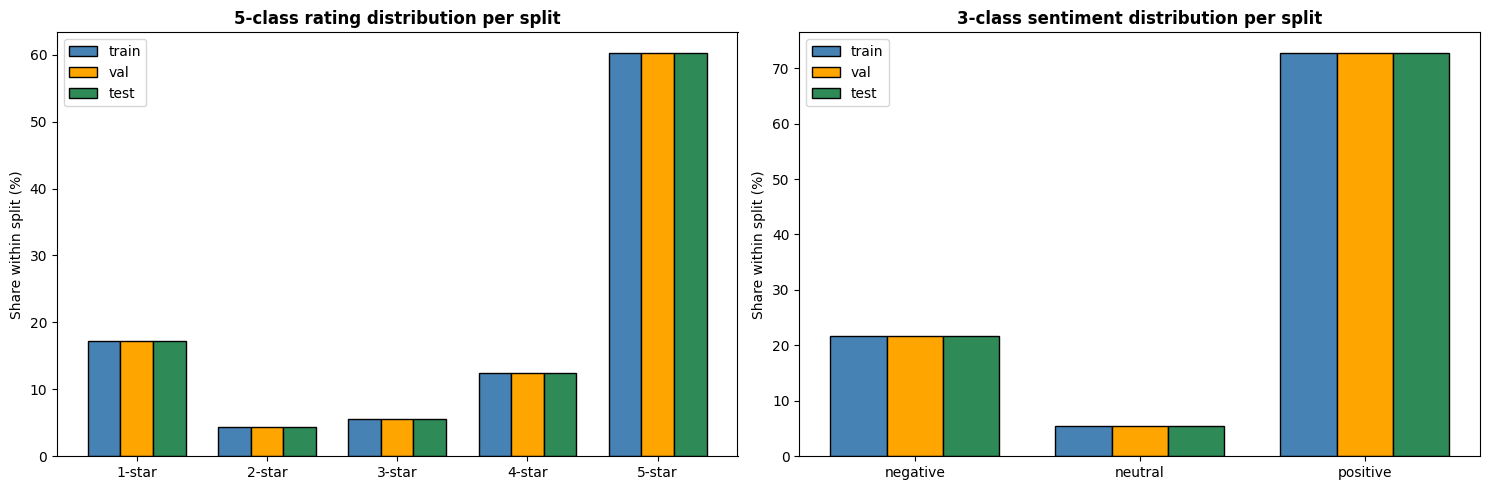

In [40]:
# Visual verification — grouped bar chart of split distributions for both tasks.
# This is the figure to put in my dissertation's "Dataset splits" subsection.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: 5-class
x5 = np.arange(5)
width = 0.25
axes[0].bar(x5 - width, dist_compare["train_%"].values, width, label="train",
            color="steelblue", edgecolor="black")
axes[0].bar(x5,          dist_compare["val_%"].values,   width, label="val",
            color="orange", edgecolor="black")
axes[0].bar(x5 + width,  dist_compare["test_%"].values,  width, label="test",
            color="seagreen", edgecolor="black")
axes[0].set_xticks(x5)
axes[0].set_xticklabels([f"{r}-star" for r in [1, 2, 3, 4, 5]])
axes[0].set_ylabel("Share within split (%)")
axes[0].set_title("5-class rating distribution per split", fontweight="bold")
axes[0].legend()

# Right: 3-class
x3 = np.arange(3)
axes[1].bar(x3 - width, dist_3_compare["train_%"].values, width, label="train",
            color="steelblue", edgecolor="black")
axes[1].bar(x3,          dist_3_compare["val_%"].values,   width, label="val",
            color="orange", edgecolor="black")
axes[1].bar(x3 + width,  dist_3_compare["test_%"].values,  width, label="test",
            color="seagreen", edgecolor="black")
axes[1].set_xticks(x3)
axes[1].set_xticklabels(["negative", "neutral", "positive"])
axes[1].set_ylabel("Share within split (%)")
axes[1].set_title("3-class sentiment distribution per split", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

In [41]:
# Integrity checks — catch silent bugs before they contaminate training.

# 1) No overlapping UIDs between splits. Since UID is globally unique in
#    MHARD, any overlap means a row appears in more than one split —
#    which would leak test information into training. Fatal bug if missed.
train_uids = set(train_df["UID"])
val_uids   = set(val_df["UID"])
test_uids  = set(test_df["UID"])

overlap_tv = train_uids & val_uids
overlap_tt = train_uids & test_uids
overlap_vt = val_uids & test_uids

assert not overlap_tv, f"Train/Val overlap: {len(overlap_tv)} UIDs"
assert not overlap_tt, f"Train/Test overlap: {len(overlap_tt)} UIDs"
assert not overlap_vt, f"Val/Test overlap: {len(overlap_vt)} UIDs"
print("No UID overlap between splits (train/val/test are disjoint)")

# 2) Every class present in every split (no class was entirely missed).
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    rating_classes_present = sorted(split_df["rating"].unique())
    assert rating_classes_present == [1, 2, 3, 4, 5], \
        f"{split_name} missing rating class: {rating_classes_present}"
    sentiment_classes_present = sorted(split_df["label_3class"].unique())
    assert sentiment_classes_present == [0, 1, 2], \
        f"{split_name} missing sentiment class: {sentiment_classes_present}"
print("All 5 rating classes and all 3 sentiment classes present in every split")

# 3) Total count matches
assert len(train_df) + len(val_df) + len(test_df) == len(df_clean), \
    "Split sizes do not sum to total"
print("Split sizes sum to total row count")

# 4) Minimum class size check — for the 3-class test set, how many neutral
#    samples do we have? If this number is very small (<500), test-set
#    metrics on the neutral class will be noisy.
neutral_test = (test_df["label_3class"] == 1).sum()
minority_5class_test = (test_df["rating"] == 2).sum()
print(f"\nMinority class sizes in TEST set:")
print(f"  3-class neutral  : {neutral_test:,} samples  "
      f"({'sufficient' if neutral_test >= 500 else 'LOW — metrics will be noisy'})")
print(f"  5-class 2-star   : {minority_5class_test:,} samples  "
      f"({'sufficient' if minority_5class_test >= 500 else 'LOW — metrics will be noisy'})")

No UID overlap between splits (train/val/test are disjoint)
All 5 rating classes and all 3 sentiment classes present in every split
Split sizes sum to total row count

Minority class sizes in TEST set:
  3-class neutral  : 1,110 samples  (sufficient)
  5-class 2-star   : 892 samples  (sufficient)


In [42]:
# set aside a LLM-preds-on-test-set slice right now so when
# we get to the baseline comparison section, we don't have to re-derive it.
# We keep it as a separate DataFrame indexed by UID. This also serves as
# documentation of EXACTLY which rows the LLM baselines will be scored on.

llm_eval_cols = ["UID", "rating", "label_5class", "label_3class"] + \
                llm_cols + [c + "_3class" for c in llm_cols]
test_llm_preds = test_df[llm_eval_cols].copy()

print(f"LLM baseline evaluation slice prepared : {test_llm_preds.shape[0]:,} rows")
print(f"LLM prediction columns (5-class)       : {len(llm_cols)}")
print(f"LLM prediction columns (3-class)       : {len(llm_cols)} (remapped)")
print("\nThis DataFrame will be used in Step 17 (LLM baseline comparison)")
print("to score each LLM on the same test set DistilBERT is evaluated on.")
test_llm_preds.head(3)

LLM baseline evaluation slice prepared : 20,082 rows
LLM prediction columns (5-class)       : 7
LLM prediction columns (3-class)       : 7 (remapped)

This DataFrame will be used in Step 17 (LLM baseline comparison)
to score each LLM on the same test set DistilBERT is evaluated on.


,UID,rating,label_5class,label_3class,pred_gpt3.5instruct,pred_gpt3.5turbo,pred_gpt4,pred_gemini1.5flash,pred_gemini1.5pro,pred_llama3.1_8b,pred_llama3.3_70b,pred_gpt3.5instruct_3class,pred_gpt3.5turbo_3class,pred_gpt4_3class,pred_gemini1.5flash_3class,pred_gemini1.5pro_3class,pred_llama3.1_8b_3class,pred_llama3.3_70b_3class
0,35510,5,4,2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1,2570,1,0,0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,140771,1,0,0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


### Step 11: Convert splits to Hugging Face Datasets + tokenize with DistilBERT

In [43]:
# Convert the three pandas splits into Hugging Face Dataset objects, and wrap
# them in a DatasetDict. Why bother? Three reasons:
#
#   1) Memory: HF Datasets uses Apache Arrow under the hood, which is
#      columnar and memory-mapped. A 200k-row pandas DataFrame holding
#      strings can easily be 500+ MB; the Arrow version is ~3-5x smaller
#      AND is read from disk on-demand instead of held in RAM.
#
#   2) Batched .map(): tokenization via HF is batched and parallelised.
#      Doing the same thing in pandas with a row-wise apply is ~10x slower.
#
#   3) Trainer integration: HF's Trainer expects a Dataset object. Using
#      pandas would force us to write a custom torch Dataset class, which
#      is extra boilerplate for no benefit here.
#
# We only carry the columns we need for training: the text ("review"), both
# label columns, and UID (kept for the methodological audit trail — not
# used during training itself).

keep_cols = ["UID", "review", "label_5class", "label_3class"]

train_ds_raw = Dataset.from_pandas(train_df[keep_cols].reset_index(drop=True))
val_ds_raw   = Dataset.from_pandas(val_df[keep_cols].reset_index(drop=True))
test_ds_raw  = Dataset.from_pandas(test_df[keep_cols].reset_index(drop=True))

hf_datasets = DatasetDict({
    "train":      train_ds_raw,
    "validation": val_ds_raw,
    "test":       test_ds_raw,
})

print("=" * 70)
print("HUGGING FACE DATASET DICT CREATED")
print("=" * 70)
print(hf_datasets)

HUGGING FACE DATASET DICT CREATED
DatasetDict({
    train: Dataset({
        features: ['UID', 'review', 'label_5class', 'label_3class'],
        num_rows: 160649
    })
    validation: Dataset({
        features: ['UID', 'review', 'label_5class', 'label_3class'],
        num_rows: 20081
    })
    test: Dataset({
        features: ['UID', 'review', 'label_5class', 'label_3class'],
        num_rows: 20082
    })
})


In [44]:
# Initialize the DistilBERT tokenizer and the model name I'll use throughout.
# We do this once, centrally, so both Task A and Task B use the IDENTICAL
# tokenization — that's a requirement for comparing the two tasks fairly.
#
# We use distilbert-base-uncased (66M params) rather than cased or base-bert
# because:
#   - App reviews are informal. Casing is inconsistent ("LOVE" vs "Love" vs
#     "love") so uncased actually helps here.
#   - DistilBERT is 40% smaller and 60% faster than BERT-base at ~97% of
#     its accuracy. That speed + size advantage is core to the carbon
#     argument in your thesis.
#   - You already validated this choice in your earlier notebook.

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded : {MODEL_NAME}")
print(f"Vocab size       : {tokenizer.vocab_size:,}")
print(f"Model max length : {tokenizer.model_max_length}")
print(f"Our max_length   : {MAX_LENGTH}  (committed in Step 6)")

Tokenizer loaded : distilbert-base-uncased
Vocab size       : 30,522
Model max length : 512
Our max_length   : 128  (committed in Step 6)


In [45]:
# Tokenization function.
#
# Critical choice: padding=False here.
# WHY: we want DYNAMIC padding (pad each batch to the longest sample IN THAT
# BATCH) rather than STATIC padding (pad every sample to max_length=128).
# Since the median review is only 30 tokens and max_length is 128, static
# padding would waste ~4x the compute on padding tokens the model ignores.
# Dynamic padding is handled by DataCollatorWithPadding at training time.
# This is a direct carbon saving — less wasted compute per step, same
# model quality.
#
# truncation=True ensures the 0.55% of reviews over 128 tokens get cut;
# we accepted this trade in Step 6.

def tokenize_fn(batch):
    return tokenizer(
        batch["review"],
        truncation=True,
        padding=False,           # dynamic padding comes later at batch time
        max_length=MAX_LENGTH,
    )

# Apply in batches of 1000 rows for speed. batched=True is where the big
# performance win happens — the tokenizer vectorises across the batch.
tokenized = hf_datasets.map(
    tokenize_fn,
    batched=True,
    batch_size=1000,
    desc="Tokenizing",
)

# Remove the raw text now that it's been encoded — the Trainer doesn't need
# it anymore, and keeping it around would bloat memory during training.
tokenized = tokenized.remove_columns(["review"])

print("\nTokenization complete.")
print(tokenized)

Tokenizing:   0%|          | 0/160649 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/20081 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/20082 [00:00<?, ? examples/s]


Tokenization complete.
DatasetDict({
    train: Dataset({
        features: ['UID', 'label_5class', 'label_3class', 'input_ids', 'attention_mask'],
        num_rows: 160649
    })
    validation: Dataset({
        features: ['UID', 'label_5class', 'label_3class', 'input_ids', 'attention_mask'],
        num_rows: 20081
    })
    test: Dataset({
        features: ['UID', 'label_5class', 'label_3class', 'input_ids', 'attention_mask'],
        num_rows: 20082
    })
})


In [46]:
# Verify token length distribution AFTER tokenization — should match the
# empirical measurements from Step 6. If it doesn't, something went wrong
# (wrong tokenizer, wrong text column, etc).

sample_lens = [len(x) for x in tokenized["train"]["input_ids"][:3000]]
print(f"Post-tokenization token length stats (3,000 train samples):")
print(f"  mean   : {np.mean(sample_lens):.1f}")
print(f"  median : {np.median(sample_lens):.0f}")
print(f"  95th % : {np.percentile(sample_lens, 95):.0f}")
print(f"  99th % : {np.percentile(sample_lens, 99):.0f}")
print(f"  max    : {max(sample_lens)}")
print(f"\nReminder from Step 6 (2,000-sample preview):")
print(f"  mean=39.1, median=30, 95th=107, 99th=124, max=165")
print("These should be very close. If the max in our post-tokenization set")
print("is 128 (not 165), that's correct — it confirms truncation worked.")

Post-tokenization token length stats (3,000 train samples):
  mean   : 39.8
  median : 31
  95th % : 107
  99th % : 125
  max    : 128

Reminder from Step 6 (2,000-sample preview):
  mean=39.1, median=30, 95th=107, 99th=124, max=165
These should be very close. If the max in our post-tokenization set
is 128 (not 165), that's correct — it confirms truncation worked.


In [47]:
# Create the two task-specific views by renaming the appropriate label
# column to 'label' (which is what HF's Trainer expects by default) and
# dropping the unused one. We do NOT re-tokenize — the text encoding is
# the same for both tasks, only the label differs.
#
# Also drop UID here because HF Trainer will try to convert every column
# to tensors when format='torch', and UID is an integer that would be
# silently included in the model input if we left it in.

# Task A — 5-class
tokenized_5class = (tokenized
    .remove_columns(["label_3class", "UID"])
    .rename_column("label_5class", "label")
)

# Task B — 3-class
tokenized_3class = (tokenized
    .remove_columns(["label_5class", "UID"])
    .rename_column("label_3class", "label")
)

# Set format to PyTorch tensors for direct consumption by the model.
tokenized_5class.set_format(type="torch")
tokenized_3class.set_format(type="torch")

print("TASK A (5-class) dataset:")
print(tokenized_5class)
print()
print("TASK B (3-class) dataset:")
print(tokenized_3class)

TASK A (5-class) dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 160649
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 20081
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 20082
    })
})

TASK B (3-class) dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 160649
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 20081
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 20082
    })
})


In [48]:
# Sanity-check one sample from each task. We want to see:
#   - input_ids: a tensor of integer token IDs, starting with 101 (CLS) and
#     ending with 102 (SEP)
#   - attention_mask: a tensor of 1s for real tokens, 0s for padding (should
#     be all 1s since we haven't padded yet — dynamic padding happens at
#     batch time)
#   - label: an integer tensor in the right range for each task

print("=" * 70)
print("SAMPLE INSPECTION — Task A (5-class)")
print("=" * 70)
sample_a = tokenized_5class["train"][0]
print(f"input_ids (first 30)  : {sample_a['input_ids'][:30].tolist()}")
print(f"attention_mask (first 30): {sample_a['attention_mask'][:30].tolist()}")
print(f"label                 : {sample_a['label'].item()}  "
      f"({label_mapping_5class[sample_a['label'].item()]})")
print(f"Decoded back to text  : {tokenizer.decode(sample_a['input_ids'])}")

print("\n" + "=" * 70)
print("SAMPLE INSPECTION — Task B (3-class)")
print("=" * 70)
sample_b = tokenized_3class["train"][0]
print(f"input_ids (first 30)  : {sample_b['input_ids'][:30].tolist()}")
print(f"attention_mask (first 30): {sample_b['attention_mask'][:30].tolist()}")
print(f"label                 : {sample_b['label'].item()}  "
      f"({label_mapping_3class[sample_b['label'].item()]})")
print(f"Decoded back to text  : {tokenizer.decode(sample_b['input_ids'])}")

# Both samples should come from the SAME training row (since we split once
# and tokenized once), just with different label columns exposed. The text
# should be identical — this is the proof that Task A and Task B are
# operating on the same data.
assert sample_a['input_ids'].tolist() == sample_b['input_ids'].tolist(), \
    "Task A and Task B are looking at different text — shouldn't happen"
print("\nBoth tasks see identical input text. Label columns differ as expected.")

SAMPLE INSPECTION — Task A (5-class)
input_ids (first 30)  : [101, 6919, 10439, 2000, 3218, 13804, 1998, 2568, 20938, 1012, 1996, 7284, 2015, 2024, 2200, 14044, 1012, 3606, 2022, 2409, 1010, 2028, 2074, 3791, 1037, 25309, 2000, 19960, 17570, 1010]
attention_mask (first 30): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
label                 : 4  (5-star)
Decoded back to text  : [CLS] wonderful app to practice meditation and mindfulness. the animations are very helpful. truth be told, one just needs a timer to meditate, but with the streak counter, you get nudged into keeping your streak going and practice mindfulness every day. [SEP]

SAMPLE INSPECTION — Task B (3-class)
input_ids (first 30)  : [101, 6919, 10439, 2000, 3218, 13804, 1998, 2568, 20938, 1012, 1996, 7284, 2015, 2024, 2200, 14044, 1012, 3606, 2022, 2409, 1010, 2028, 2074, 3791, 1037, 25309, 2000, 19960, 17570, 1010]
attention_mask (first 30): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

### Step 12: Load DistilBERT, build weighted-loss custom Trainer, define metrics

In [49]:
# This step sets up the TRAINING MACHINERY that both tasks will share.
# Concretely, it defines:
#   (a) a factory for loading DistilBERT with the right classification head
#   (b) a WeightedLossTrainer class that handles class imbalance
#   (c) a compute_metrics function that reports accuracy + weighted F1 +
#       macro F1 + MAE (the last one only meaningful for the 5-class task)
#   (d) the data collator for dynamic padding
#
# Nothing is task-specific yet — we'll instantiate the actual Trainers in
# Step 13 (Task A) and Step 15 (Task B) using these shared building blocks.

import torch.nn as nn
from torch.utils.data import WeightedRandomSampler

# --- (a) Model factory ---------------------------------------------------
# We wrap the from_pretrained call in a small function so Task A and Task B
# can each instantiate a FRESH model with the right num_labels. Critically:
# each task gets its OWN model — we do NOT fine-tune one head then swap
# heads for the other task, because that would conflate Task A and B
# parameters and invalidate the comparison.

def build_distilbert(num_labels, id2label, label2id):
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        # Drop the existing classification head from any previous load —
        # we always start from the pretrained encoder with a fresh head.
        ignore_mismatched_sizes=True,
    )
    model.to(DEVICE)
    return model

print(f"Model factory ready. Will instantiate from: {MODEL_NAME}")
print(f"Device target: {DEVICE}")

Model factory ready. Will instantiate from: distilbert-base-uncased
Device target: cuda


In [50]:
# --- (b) Weighted-loss Trainer --------------------------------------------
# The standard HF Trainer computes CrossEntropyLoss with uniform weights,
# which will cause our 5-star-heavy model to just predict "5" most of the
# time. We subclass and inject class weights into the loss.
#
# The class weights come from Step 5 (balanced inverse-frequency).
#
# Why subclassing instead of a callback: the loss function is computed
# INSIDE the Trainer's compute_loss method. Passing it in any other way
# requires monkey-patching. Subclassing is the idiomatic HF way.

class WeightedLossTrainer(Trainer):
    """Custom Trainer that uses a class-weighted CrossEntropyLoss.

    Pass a torch.Tensor of shape (num_classes,) as `class_weights` when
    instantiating. The tensor will be moved to the model's device
    automatically so we don't get device-mismatch errors.
    """
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        if class_weights is not None:
            # Move weights to the same device as the model
            self.class_weights = class_weights.to(self.model.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fn = nn.CrossEntropyLoss()

        loss = loss_fn(logits.view(-1, self.model.config.num_labels),
                       labels.view(-1))
        return (loss, outputs) if return_outputs else loss


print("WeightedLossTrainer defined.")
print("It accepts `class_weights=torch.tensor([...])` in its constructor.")

WeightedLossTrainer defined.
It accepts `class_weights=torch.tensor([...])` in its constructor.


In [51]:
# --- (c) Compute-metrics functions ----------------------------------------
# One function per task so each Trainer gets the right set of metrics.
# Accuracy and F1 are standard. The extra detail:
#
#   - weighted F1 = F1 weighted by support (class size). This is the
#     standard "single number" summary for imbalanced multi-class.
#   - macro F1 = unweighted mean of per-class F1. THIS IS THE NUMBER THAT
#     ACTUALLY MATTERS for imbalanced data, because it treats all classes
#     equally — a model that ignores the neutral class gets punished here
#     but could still look good on weighted F1.
#   - MAE is only meaningful for the 5-class ordinal task. A prediction of
#     4 for a true rating of 5 is a smaller mistake than a prediction of 1.
#     Accuracy can't see that distinction; MAE can.

def compute_metrics_5class(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    # Convert back to the 1..5 scale for MAE (labels are 0..4)
    return {
        "accuracy":     accuracy_score(labels, preds),
        "f1_weighted":  f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro":     f1_score(labels, preds, average="macro",    zero_division=0),
        "mae_stars":    mean_absolute_error(labels + 1, preds + 1),
    }

def compute_metrics_3class(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":     accuracy_score(labels, preds),
        "f1_weighted":  f1_score(labels, preds, average="weighted", zero_division=0),
        "f1_macro":     f1_score(labels, preds, average="macro",    zero_division=0),
    }

print("Metrics functions defined:")
print("  5-class: accuracy, f1_weighted, f1_macro, mae_stars")
print("  3-class: accuracy, f1_weighted, f1_macro")

Metrics functions defined:
  5-class: accuracy, f1_weighted, f1_macro, mae_stars
  3-class: accuracy, f1_weighted, f1_macro


In [52]:
# --- (d) Data collator & class-weight tensors ----------------------------
# DataCollatorWithPadding implements the dynamic padding we committed to
# in Step 11 — it pads each batch to the longest sample in that batch.
# Shared across both tasks because padding is task-agnostic.

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Convert the class weights from Step 5 into torch tensors. Keep both
# versions accessible by task so the right one goes into the right Trainer.

class_weights_5 = torch.tensor(weights_5, dtype=torch.float)
class_weights_3 = torch.tensor(weights_3, dtype=torch.float)

print("Data collator ready (dynamic padding per batch).")
print()
print("Class weights (Task A, 5-class):")
for i, w in enumerate(class_weights_5.tolist()):
    print(f"  {i+1}-star   -> weight {w:.4f}")
print()
print("Class weights (Task B, 3-class):")
for name, w in zip(["negative", "neutral", "positive"], class_weights_3.tolist()):
    print(f"  {name:<9} -> weight {w:.4f}")

Data collator ready (dynamic padding per batch).

Class weights (Task A, 5-class):
  1-star   -> weight 1.1623
  2-star   -> weight 4.5046
  3-star   -> weight 3.6175
  4-star   -> weight 1.6014
  5-star   -> weight 0.3315

Class weights (Task B, 3-class):
  negative  -> weight 1.5398
  neutral   -> weight 6.0292
  positive  -> weight 0.4577


In [53]:
# --- Final pre-training sanity check --------------------------------------
# Spin up a tiny dry-run model, push one batch through, and verify the
# weighted loss is actually being applied. This catches silent
# class_weights=None bugs BEFORE we burn an hour of GPU time.

dry_model = build_distilbert(
    num_labels=5,
    id2label=id2label_5,
    label2id=label2id_5,
)

# Take a 4-sample slice of the train set, collate it manually, and run
# a single forward pass with both weighted and unweighted loss.
sample_batch = [tokenized_5class["train"][i] for i in range(4)]
batch = data_collator(sample_batch)
batch = {k: v.to(DEVICE) for k, v in batch.items()}

dry_model.eval()
with torch.no_grad():
    outputs = dry_model(**{k: v for k, v in batch.items() if k != "labels"})
    logits = outputs.logits

    loss_unweighted = nn.CrossEntropyLoss()(logits, batch["labels"])
    loss_weighted = nn.CrossEntropyLoss(
        weight=class_weights_5.to(DEVICE)
    )(logits, batch["labels"])

print(f"Dry-run forward pass: {logits.shape} (batch_size=4, num_labels=5)")
print(f"Unweighted loss : {loss_unweighted.item():.4f}")
print(f"Weighted loss   : {loss_weighted.item():.4f}")
print(f"(These should differ — if they're equal, class weights are NOT being used)")

# Clean up the dry-run model so it doesn't hold GPU memory
del dry_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nDry-run complete. GPU memory cleared.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dry-run forward pass: torch.Size([4, 5]) (batch_size=4, num_labels=5)
Unweighted loss : 1.6077
Weighted loss   : 1.5808
(These should differ — if they're equal, class weights are NOT being used)

Dry-run complete. GPU memory cleared.


### Step 13: Task A training setup + launch (5-class, with CodeCarbon)

In [54]:
# --- Cell 13.1: Output paths -----------------------------------------------
# Strategy: write intermediate checkpoints to /content/ (fast local SSD)
# during training, and copy the FINAL model + emissions log to Drive for
# persistence. Writing checkpoints directly to Drive on every eval step
# is very slow because Drive's sync layer has high latency — it can slow
# training by 2-3x. Local-during-train, sync-at-end is the Colab best
# practice.

import os
import shutil
from datetime import datetime

# Local (fast) training directory — wiped at session end, that's fine
LOCAL_OUTPUT_5 = "/content/distilbert_5class_tmp"

# Drive (persistent) destination for final artifacts
DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks/DistilBERT"
DRIVE_FINAL_5   = f"{DRIVE_BASE}/distilbert_5class_final"
DRIVE_EMISSIONS = f"{DRIVE_BASE}/emissions"

os.makedirs(LOCAL_OUTPUT_5, exist_ok=True)
os.makedirs(DRIVE_FINAL_5,   exist_ok=True)
os.makedirs(DRIVE_EMISSIONS, exist_ok=True)

print(f"Local training dir   : {LOCAL_OUTPUT_5}")
print(f"Final model dir      : {DRIVE_FINAL_5}")
print(f"Emissions log dir    : {DRIVE_EMISSIONS}")

Local training dir   : /content/distilbert_5class_tmp
Final model dir      : /content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_5class_final
Emissions log dir    : /content/drive/MyDrive/Colab Notebooks/DistilBERT/emissions


In [55]:
# --- Cell 13.2: TrainingArguments for Task A -------------------------------
# Every hyperparameter below is chosen for a reason. The inline comments
# double as notes you can paraphrase directly into your methodology section.

BATCH_SIZE    = 32      # standard for DistilBERT on T4; fits fp16 with headroom
NUM_EPOCHS    = 3       # 3 is enough for fine-tuning a pretrained model on this data size
LEARNING_RATE = 2e-5    # canonical DistilBERT fine-tune LR; stable under class-weighted loss
WEIGHT_DECAY  = 0.01    # light regularisation, stock AdamW default
WARMUP_RATIO  = 0.1     # 10% warmup ramps LR from 0 to peak — helps stability

training_args_5 = TrainingArguments(
    output_dir                  = LOCAL_OUTPUT_5,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,   # no backward pass, can be bigger
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,

    # fp16 mixed-precision: halves GPU memory and speeds training ~40%
    # with effectively zero accuracy cost. Direct carbon saving.
    fp16                        = True,

    # Evaluate + save once per epoch. With 3 epochs that's 3 evals total —
    # enough granularity for early stopping without wasting compute on
    # frequent evals.
    eval_strategy               = "epoch",
    save_strategy               = "epoch",

    # Keep at most 2 checkpoints on disk (current best + previous) so we
    # don't fill up the local SSD with duplicates.
    save_total_limit            = 2,

    # Critical: at the end, load the checkpoint with the BEST f1_macro on
    # validation. Not accuracy, not loss — macro F1, because that's the
    # imbalance-aware metric that matters for our minority classes.
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,

    # Logging: print training loss every 50 steps (~250 times across the
    # run). Enough to see the loss curve, not so much it floods output.
    logging_dir                 = f"{LOCAL_OUTPUT_5}/logs",
    logging_steps               = 50,

    # Reproducibility
    seed                        = RANDOM_SEED,
    data_seed                   = RANDOM_SEED,

    # Don't report to wandb/tensorboard/hub — keep it self-contained
    report_to                   = "none",
    push_to_hub                 = False,

    # dataloader workers: 2 is safe on Colab; higher sometimes hangs
    dataloader_num_workers      = 2,

    # Lets us skip the default prediction on test set at end of training —
    # we'll call trainer.evaluate() explicitly on test afterwards
    do_predict                  = False,
)

# Derived training stats — useful for the methodology section
steps_per_epoch = len(tokenized_5class["train"]) // BATCH_SIZE
total_steps     = steps_per_epoch * NUM_EPOCHS

print("=" * 70)
print("TASK A — TrainingArguments summary")
print("=" * 70)
print(f"Train samples     : {len(tokenized_5class['train']):,}")
print(f"Validation        : {len(tokenized_5class['validation']):,}")
print(f"Batch size        : {BATCH_SIZE}  (eval: {BATCH_SIZE * 2})")
print(f"Epochs            : {NUM_EPOCHS}")
print(f"Steps per epoch   : {steps_per_epoch:,}")
print(f"Total steps       : {total_steps:,}")
print(f"Learning rate     : {LEARNING_RATE}  (warmup {WARMUP_RATIO*100:.0f}%)")
print(f"Weight decay      : {WEIGHT_DECAY}")
print(f"Precision         : fp16")
print(f"Best-model metric : f1_macro (validation)")
print("=" * 70)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TASK A — TrainingArguments summary
Train samples     : 160,649
Validation        : 20,081
Batch size        : 32  (eval: 64)
Epochs            : 3
Steps per epoch   : 5,020
Total steps       : 15,060
Learning rate     : 2e-05  (warmup 10%)
Weight decay      : 0.01
Precision         : fp16
Best-model metric : f1_macro (validation)


In [56]:
# --- Cell 13.3 (FIXED): Instantiate the Task A model + Trainer ------------
# Fresh model so training starts from the clean pretrained encoder.
# We set the seed again IMMEDIATELY before model creation so that the
# random init of the classification head is also reproducible.

set_seed(RANDOM_SEED)

model_5 = build_distilbert(
    num_labels = 5,
    id2label   = id2label_5,
    label2id   = label2id_5,
)

total_params     = sum(p.numel() for p in model_5.parameters())
trainable_params = sum(p.numel() for p in model_5.parameters() if p.requires_grad)

print(f"Model device        : {next(model_5.parameters()).device}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model dtype         : {next(model_5.parameters()).dtype}")

# Instantiate the weighted-loss Trainer with early stopping.
# NOTE: transformers 4.46+ renamed `tokenizer` to `processing_class`.
# Using the new name keeps us compatible with current and future versions.
trainer_5 = WeightedLossTrainer(
    model            = model_5,
    args             = training_args_5,
    train_dataset    = tokenized_5class["train"],
    eval_dataset     = tokenized_5class["validation"],
    processing_class = tokenizer,      # <-- was tokenizer=tokenizer
    data_collator    = data_collator,
    compute_metrics  = compute_metrics_5class,
    class_weights    = class_weights_5,
    callbacks        = [
        EarlyStoppingCallback(
            early_stopping_patience  = 2,
            early_stopping_threshold = 0.001,
        )
    ],
)

print("\nTrainer for Task A (5-class) is ready.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model device        : cuda:0
Total parameters    : 66,957,317
Trainable parameters: 66,957,317
Model dtype         : torch.float32

Trainer for Task A (5-class) is ready.


In [57]:
# --- Cell 13.4: Pre-flight check ------------------------------------------
# Last confirmation before burning GPU time. If anything in the stats below
print("=" * 70)
print("TASK A PRE-FLIGHT")
print("=" * 70)
print(f"Model                : {MODEL_NAME}  ({total_params/1e6:.1f}M params)")
print(f"Classes              : 5  ({list(id2label_5.values())})")
print(f"Train batches/epoch  : {steps_per_epoch:,}")
print(f"Total training steps : {total_steps:,}")
print(f"Expected duration    : ~25-40 min on T4 GPU (fp16)")
print(f"                       ~15-25 min on L4/A100")
print(f"Early stopping       : patience=2 on f1_macro")
print(f"Class imbalance      : max/min = {weights_5.max()/weights_5.min():.2f}x "
      f"(handled via weighted CE)")
print(f"Emissions tracking   : CodeCarbon (output to {DRIVE_EMISSIONS})")
print("=" * 70)
print("\nWhen you run the next cell, training will start immediately.")
print("You can monitor progress in the cell output — loss should drop")
print("steadily and macro F1 on validation should improve each epoch.")

TASK A PRE-FLIGHT
Model                : distilbert-base-uncased  (67.0M params)
Classes              : 5  (['1-star', '2-star', '3-star', '4-star', '5-star'])
Train batches/epoch  : 5,020
Total training steps : 15,060
Expected duration    : ~25-40 min on T4 GPU (fp16)
                       ~15-25 min on L4/A100
Early stopping       : patience=2 on f1_macro
Class imbalance      : max/min = 13.59x (handled via weighted CE)
Emissions tracking   : CodeCarbon (output to /content/drive/MyDrive/Colab Notebooks/DistilBERT/emissions)

When you run the next cell, training will start immediately.
You can monitor progress in the cell output — loss should drop
steadily and macro F1 on validation should improve each epoch.


In [58]:
# --- Cell 13.5: Launch training with CodeCarbon tracking ------------------
# This is the cell that actually trains. Expect 25-40 minutes on T4.
#
# EmissionsTracker measures:
#   - Energy used by CPU + GPU + RAM during the tracked period
#   - Converts energy to kg CO2eq using your country's grid intensity
#     (auto-detected from IP geolocation; UK grid is ~250g CO2/kWh)
# The result is the number that makes your dissertation's efficiency
# claim concrete and defensible.

from codecarbon import EmissionsTracker
import time

# Clear GPU cache so the starting memory reading is clean
if torch.cuda.is_available():
    torch.cuda.empty_cache()

tracker_5 = EmissionsTracker(
    project_name       = "distilbert_5class_train",
    output_dir         = DRIVE_EMISSIONS,
    output_file        = "emissions_5class_train.csv",
    measure_power_secs = 30,       # sample power every 30s — low overhead
    log_level          = "error",  # suppress chatty INFO output
    save_to_file       = True,
)

print("Starting Task A training at", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("-" * 70)

t0 = time.time()
tracker_5.start()

try:
    train_result_5 = trainer_5.train()
    training_successful_5 = True
except KeyboardInterrupt:
    print("\n\nTraining interrupted by user.")
    training_successful_5 = False
except Exception as e:
    print(f"\n\nTraining failed: {e}")
    training_successful_5 = False
    raise
finally:
    emissions_5_train = tracker_5.stop()

training_time_5 = time.time() - t0

print("-" * 70)
print("TASK A TRAINING COMPLETE" if training_successful_5 else "TASK A TRAINING INCOMPLETE")
print("-" * 70)
print(f"Wall time        : {training_time_5/60:.2f} minutes "
      f"({training_time_5:.1f} seconds)")
print(f"CO2 emitted      : {emissions_5_train:.6f} kg CO2eq "
      f"({emissions_5_train*1000:.3f} g)")

if training_successful_5:
    # Show the final training loss and best-checkpoint metrics
    print(f"\nFinal training loss : {train_result_5.training_loss:.4f}")
    print(f"Training steps done : {train_result_5.global_step:,} / {total_steps:,}")
    if hasattr(trainer_5.state, "best_metric") and trainer_5.state.best_metric is not None:
        print(f"Best val f1_macro   : {trainer_5.state.best_metric:.4f}")

[codecarbon WARNING @ 15:52:01] Multiple instances of codecarbon are allowed to run at the same time.


Starting Task A training at 2026-04-24 15:52:02
----------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Mae Stars
1,0.939997,0.929147,0.745232,0.760841,0.569788,0.324934
2,0.788270,0.932139,0.705941,0.735002,0.558412,0.354464
3,0.704101,0.986542,0.725561,0.748714,0.571605,0.336686


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

----------------------------------------------------------------------
TASK A TRAINING COMPLETE
----------------------------------------------------------------------
Wall time        : 24.69 minutes (1481.6 seconds)
CO2 emitted      : 0.024806 kg CO2eq (24.806 g)

Final training loss : 0.8871
Training steps done : 15,063 / 15,060
Best val f1_macro   : 0.5716


### Step 14: Task A: test set evaluation, confusion matrix, and save

In [59]:
# --- Cell 14.1 (FIXED): Test set evaluation with inference emissions tracking ---
# Fix for "on_train_begin must be called before on_evaluate":
# HF's NotebookProgressCallback retains state across cells. Removing it
# lets trainer.evaluate() and trainer.predict() work standalone.

from transformers.utils.notebook import NotebookProgressCallback
trainer_5.remove_callback(NotebookProgressCallback)
print("NotebookProgressCallback removed — standalone evaluate/predict now safe.")

# Safely flush any leftover emissions tracker from the failed attempt.
# If the previous run created tracker_5_test but didn't stop it, CodeCarbon
# holds an open process. This try/except silently handles the "already
# stopped" or "never existed" cases.
try:
    tracker_5_test.stop()
    print("Previous tracker_5_test was flushed.")
except Exception:
    pass

from codecarbon import EmissionsTracker

if torch.cuda.is_available():
    torch.cuda.empty_cache()

tracker_5_test = EmissionsTracker(
    project_name       = "distilbert_5class_test",
    output_dir         = DRIVE_EMISSIONS,
    output_file        = "emissions_5class_test.csv",
    measure_power_secs = 15,
    log_level          = "error",
    save_to_file       = True,
)

t0 = time.time()
tracker_5_test.start()

test_results_5 = trainer_5.evaluate(tokenized_5class["test"])

emissions_5_test = tracker_5_test.stop()
inference_time_5 = time.time() - t0

n_test = len(tokenized_5class["test"])
ms_per_pred = (inference_time_5 / n_test) * 1000
mg_per_pred = (emissions_5_test / n_test) * 1_000_000

print("=" * 70)
print("TASK A — TEST SET RESULTS")
print("=" * 70)
print(f"Samples evaluated   : {n_test:,}")
print(f"Accuracy            : {test_results_5['eval_accuracy']:.4f} "
      f"({test_results_5['eval_accuracy']*100:.2f}%)")
print(f"F1 (weighted)       : {test_results_5['eval_f1_weighted']:.4f}")
print(f"F1 (macro)          : {test_results_5['eval_f1_macro']:.4f}")
print(f"MAE (stars)         : {test_results_5['eval_mae_stars']:.4f}")
print(f"Eval loss           : {test_results_5['eval_loss']:.4f}")
print("-" * 70)
print(f"Wall time           : {inference_time_5:.2f} sec")
print(f"Throughput          : {n_test/inference_time_5:.1f} samples/sec")
print(f"Latency             : {ms_per_pred:.2f} ms/sample")
print("-" * 70)
print(f"Inference CO2       : {emissions_5_test*1000:.4f} g total")
print(f"                    : {mg_per_pred:.4f} mg per prediction")
print("=" * 70)

gpt4_acc = 0.7518
print(f"\nHead-to-head preview:")
print(f"  DistilBERT 5-class accuracy : {test_results_5['eval_accuracy']:.4f}")
print(f"  GPT-4 5-class accuracy      : {gpt4_acc:.4f}")
print(f"  Delta                       : {(test_results_5['eval_accuracy']-gpt4_acc)*100:+.2f} pp")

NotebookProgressCallback removed — standalone evaluate/predict now safe.
TASK A — TEST SET RESULTS
Samples evaluated   : 20,082
Accuracy            : 0.7167 (71.67%)
F1 (weighted)       : 0.7422
F1 (macro)          : 0.5678
MAE (stars)         : 0.3489
Eval loss           : 0.9995
----------------------------------------------------------------------
Wall time           : 18.50 sec
Throughput          : 1085.7 samples/sec
Latency             : 0.92 ms/sample
----------------------------------------------------------------------
Inference CO2       : 0.2955 g total
                    : 0.0147 mg per prediction

Head-to-head preview:
  DistilBERT 5-class accuracy : 0.7167
  GPT-4 5-class accuracy      : 0.7518
  Delta                       : -3.51 pp


Generating predictions for test set...


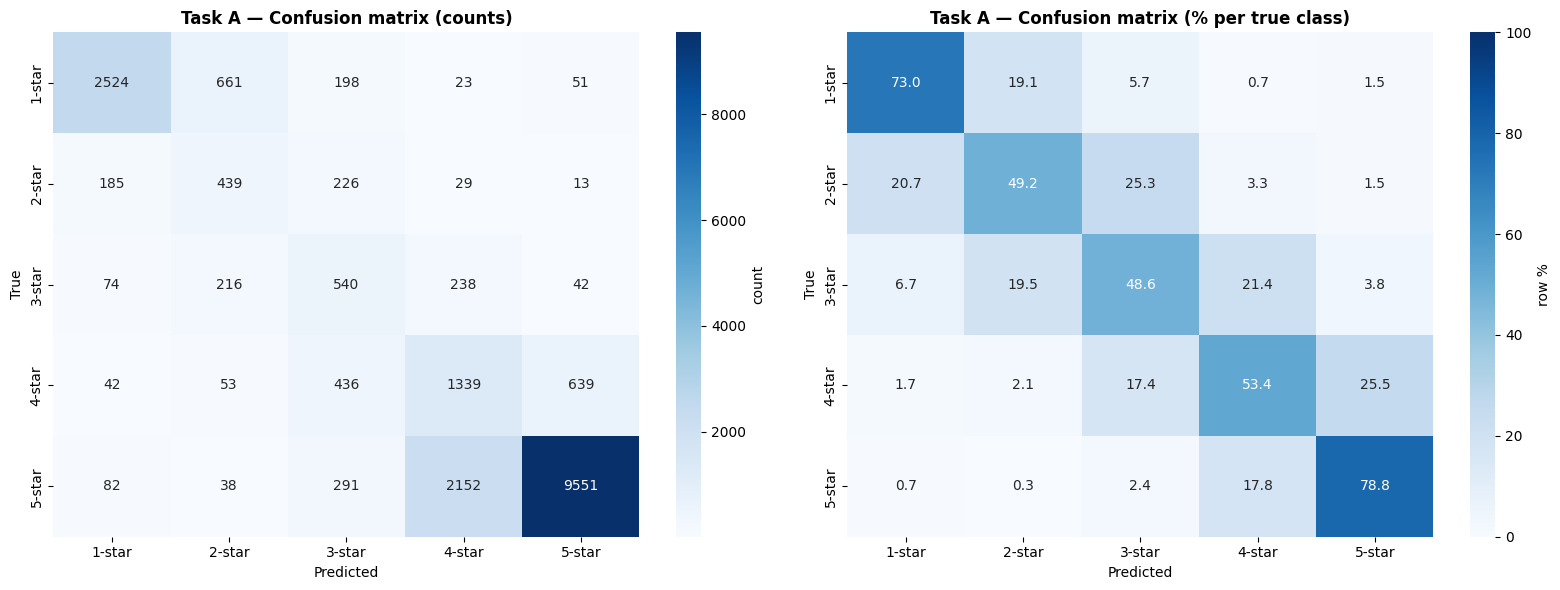

In [60]:
# --- Cell 14.2: Confusion matrix (raw + normalized) -----------------------
# Now that the callback is removed, trainer.predict() works fine too.

print("Generating predictions for test set...")
preds_output_5 = trainer_5.predict(tokenized_5class["test"])
pred_labels_5 = np.argmax(preds_output_5.predictions, axis=-1)
true_labels_5 = preds_output_5.label_ids

distilbert_preds_5class = pred_labels_5.copy()

cm_5 = confusion_matrix(true_labels_5, pred_labels_5, labels=[0, 1, 2, 3, 4])
cm_5_pct = cm_5.astype(float) / cm_5.sum(axis=1, keepdims=True) * 100

class_names_5 = [f"{i+1}-star" for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_5, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_5, yticklabels=class_names_5,
            ax=axes[0], cbar_kws={"label": "count"})
axes[0].set_title("Task A — Confusion matrix (counts)", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_5_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names_5, yticklabels=class_names_5,
            ax=axes[1], cbar_kws={"label": "row %"}, vmin=0, vmax=100)
axes[1].set_title("Task A — Confusion matrix (% per true class)",
                  fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [61]:
# --- Cell 14.3: Per-class classification report ---------------------------
report_5 = classification_report(
    true_labels_5, pred_labels_5,
    labels       = [0, 1, 2, 3, 4],
    target_names = class_names_5,
    digits       = 4,
    zero_division = 0,
)

print("=" * 70)
print("TASK A — PER-CLASS CLASSIFICATION REPORT")
print("=" * 70)
print(report_5)

from sklearn.metrics import classification_report as cr_dict
report_5_dict = cr_dict(
    true_labels_5, pred_labels_5,
    labels       = [0, 1, 2, 3, 4],
    target_names = class_names_5,
    output_dict  = True,
    zero_division = 0,
)

per_class_recall = {class_names_5[i]: report_5_dict[class_names_5[i]]["recall"]
                    for i in range(5)}
worst_class = min(per_class_recall, key=per_class_recall.get)
best_class  = max(per_class_recall, key=per_class_recall.get)
print(f"\nStrongest class (highest recall): {best_class}  "
      f"({per_class_recall[best_class]:.4f})")
print(f"Weakest class (lowest recall)  : {worst_class}  "
      f"({per_class_recall[worst_class]:.4f})")

TASK A — PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

      1-star     0.8682    0.7301    0.7932      3457
      2-star     0.3120    0.4922    0.3819       892
      3-star     0.3193    0.4865    0.3856      1110
      4-star     0.3541    0.5337    0.4258      2509
      5-star     0.9276    0.7884    0.8524     12114

    accuracy                         0.7167     20082
   macro avg     0.5563    0.6062    0.5678     20082
weighted avg     0.7848    0.7167    0.7422     20082


Strongest class (highest recall): 5-star  (0.7884)
Weakest class (lowest recall)  : 3-star  (0.4865)


In [62]:
# --- Cell 14.4: Real-world inference examples -----------------------------
test_reviews = [
    ("I absolutely love this app. It changed my life, the meditations are amazing and I use it every day. Best purchase ever.", 5),
    ("This is a decent app. It does what it says but nothing special. Would recommend for basic use.", 4),
    ("The app is okay, has some good features but also some bugs. I'm on the fence about keeping it.", 3),
    ("Expected more from this app. It's slow, the interface is confusing, and I don't find it very helpful.", 2),
    ("Complete waste of money. Crashes constantly, can't cancel the subscription, and the support never responds. Uninstalling.", 1),
    ("Honestly the best thing that happened to my mental health this year. Absolute game-changer.", 5),
    ("It has helped a little but nothing groundbreaking. I'm neutral on it.", 3),
]

model_5.eval()
print("=" * 70)
print("TASK A — QUALITATIVE INFERENCE ON UNSEEN REVIEWS")
print("=" * 70)

with torch.no_grad():
    for text, expected in test_reviews:
        enc = tokenizer(text, truncation=True, max_length=MAX_LENGTH,
                        return_tensors="pt").to(DEVICE)
        logits = model_5(**enc).logits
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred   = int(np.argmax(probs))
        match  = "correct" if (pred + 1) == expected else f"off by {abs((pred+1)-expected)}"

        print(f"\nText     : {text}")
        print(f"Expected : {expected}-star   Predicted: {pred+1}-star   [{match}]")
        print(f"Probs    : " + "  ".join(
            f"{i+1}★={p:.3f}" for i, p in enumerate(probs)))

TASK A — QUALITATIVE INFERENCE ON UNSEEN REVIEWS

Text     : I absolutely love this app. It changed my life, the meditations are amazing and I use it every day. Best purchase ever.
Expected : 5-star   Predicted: 5-star   [correct]
Probs    : 1★=0.001  2★=0.001  3★=0.001  4★=0.019  5★=0.977

Text     : This is a decent app. It does what it says but nothing special. Would recommend for basic use.
Expected : 4-star   Predicted: 3-star   [off by 1]
Probs    : 1★=0.004  2★=0.017  3★=0.700  4★=0.258  5★=0.021

Text     : The app is okay, has some good features but also some bugs. I'm on the fence about keeping it.
Expected : 3-star   Predicted: 3-star   [correct]
Probs    : 1★=0.003  2★=0.017  3★=0.613  4★=0.344  5★=0.023

Text     : Expected more from this app. It's slow, the interface is confusing, and I don't find it very helpful.
Expected : 2-star   Predicted: 2-star   [correct]
Probs    : 1★=0.049  2★=0.570  3★=0.370  4★=0.010  5★=0.001

Text     : Complete waste of money. Crashes const

In [63]:
# --- Cell 14.5: Save best model + tokenizer + metrics summary to Drive ----
import json

print("Saving Task A artifacts to Drive...")

trainer_5.save_model(DRIVE_FINAL_5)
tokenizer.save_pretrained(DRIVE_FINAL_5)

metrics_bundle_5 = {
    "task": "5-class (ordinal rating prediction)",
    "model": MODEL_NAME,
    "dataset": "MHARD",
    "num_labels": 5,
    "label_mapping": label_mapping_5class,
    "max_length": MAX_LENGTH,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "fp16": True,
        "class_weights": class_weights_5.tolist(),
        "metric_for_best_model": "f1_macro",
    },
    "splits": {
        "train": len(tokenized_5class["train"]),
        "validation": len(tokenized_5class["validation"]),
        "test": len(tokenized_5class["test"]),
    },
    "training": {
        "wall_time_seconds": training_time_5,
        "wall_time_minutes": training_time_5 / 60,
        "final_train_loss": train_result_5.training_loss,
        "global_steps": train_result_5.global_step,
        "best_val_f1_macro": trainer_5.state.best_metric,
        "emissions_kg_co2eq": emissions_5_train,
    },
    "test_results": {
        "accuracy":    test_results_5["eval_accuracy"],
        "f1_weighted": test_results_5["eval_f1_weighted"],
        "f1_macro":    test_results_5["eval_f1_macro"],
        "mae_stars":   test_results_5["eval_mae_stars"],
        "loss":        test_results_5["eval_loss"],
        "inference_seconds": inference_time_5,
        "throughput_samples_per_sec": n_test / inference_time_5,
        "latency_ms_per_sample": ms_per_pred,
        "emissions_kg_co2eq": emissions_5_test,
        "emissions_mg_per_prediction": mg_per_pred,
    },
    "per_class_report": report_5_dict,
}

metrics_path_5 = f"{DRIVE_FINAL_5}/metrics_summary.json"
with open(metrics_path_5, "w") as f:
    json.dump(metrics_bundle_5, f, indent=2)

with open(f"{DRIVE_FINAL_5}/label_mapping.json", "w") as f:
    json.dump(label_mapping_5class, f, indent=2)

print(f"\nModel saved to        : {DRIVE_FINAL_5}")
print(f"Metrics saved to      : {metrics_path_5}")

print(f"\nContents of {DRIVE_FINAL_5}:")
for fname in sorted(os.listdir(DRIVE_FINAL_5)):
    fpath = os.path.join(DRIVE_FINAL_5, fname)
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  - {fname:<30}  {size_mb:>8.2f} MB")

Saving Task A artifacts to Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to        : /content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_5class_final
Metrics saved to      : /content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_5class_final/metrics_summary.json

Contents of /content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_5class_final:
  - config.json                         0.00 MB
  - label_mapping.json                  0.00 MB
  - metrics_summary.json                0.00 MB
  - model.safetensors                 255.43 MB
  - test_predictions.npz                0.23 MB
  - tokenizer.json                      0.68 MB
  - tokenizer_config.json               0.00 MB
  - training_args.bin                   0.01 MB


### Step 15: Task B training setup + launch (3-class, 2 epochs)

In [64]:
# --- Cell 15.1: Output paths for Task B -----------------------------------
# Separate local + Drive directories so the two task models never overwrite
# each other. Same local-SSD-during-train, sync-to-Drive-at-end pattern.

LOCAL_OUTPUT_3 = "/content/distilbert_3class_tmp"
DRIVE_FINAL_3  = f"{DRIVE_BASE}/distilbert_3class_final"

os.makedirs(LOCAL_OUTPUT_3, exist_ok=True)
os.makedirs(DRIVE_FINAL_3,  exist_ok=True)

print(f"Local training dir   : {LOCAL_OUTPUT_3}")
print(f"Final model dir      : {DRIVE_FINAL_3}")

Local training dir   : /content/distilbert_3class_tmp
Final model dir      : /content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_3class_final


In [65]:
# --- Cell 15.2: TrainingArguments for Task B ------------------------------
# KEY DIFFERENCE from Task A: NUM_EPOCHS reduced from 3 to 2.
#
# Why: Task A's logs showed val_f1_macro at epoch 1 was 0.5698, epoch 3 was
# 0.5716 — essentially flat after epoch 1. Training for 3 epochs on this
# data doesn't buy meaningful quality improvement, it just burns emissions.
# The 3-class problem is strictly easier (fewer boundaries to learn) so if
# anything 2 epochs is more than enough here. We save ~1/3 of the training
# emissions with no expected quality loss — this is the carbon-aware
# methodology that makes the paper's story coherent.
#
# Everything else (LR, batch size, weight decay, fp16, best-metric) stays
# identical to Task A so the two tasks are directly comparable.

NUM_EPOCHS_3 = 2   # reduced from 3 based on Task A convergence pattern

training_args_3 = TrainingArguments(
    output_dir                  = LOCAL_OUTPUT_3,
    num_train_epochs            = NUM_EPOCHS_3,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE * 2,
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_ratio                = WARMUP_RATIO,
    fp16                        = True,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    greater_is_better           = True,
    logging_dir                 = f"{LOCAL_OUTPUT_3}/logs",
    logging_steps               = 50,
    seed                        = RANDOM_SEED,
    data_seed                   = RANDOM_SEED,
    report_to                   = "none",
    push_to_hub                 = False,
    dataloader_num_workers      = 2,
    do_predict                  = False,
)

steps_per_epoch_3 = len(tokenized_3class["train"]) // BATCH_SIZE
total_steps_3     = steps_per_epoch_3 * NUM_EPOCHS_3

print("=" * 70)
print("TASK B — TrainingArguments summary")
print("=" * 70)
print(f"Train samples     : {len(tokenized_3class['train']):,}")
print(f"Validation        : {len(tokenized_3class['validation']):,}")
print(f"Batch size        : {BATCH_SIZE}  (eval: {BATCH_SIZE * 2})")
print(f"Epochs            : {NUM_EPOCHS_3}  (reduced from 3 — Task A converged at epoch 1)")
print(f"Steps per epoch   : {steps_per_epoch_3:,}")
print(f"Total steps       : {total_steps_3:,}")
print(f"Learning rate     : {LEARNING_RATE}  (warmup {WARMUP_RATIO*100:.0f}%)")
print(f"Precision         : fp16")
print(f"Best-model metric : f1_macro (validation)")
print("=" * 70)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TASK B — TrainingArguments summary
Train samples     : 160,649
Validation        : 20,081
Batch size        : 32  (eval: 64)
Epochs            : 2  (reduced from 3 — Task A converged at epoch 1)
Steps per epoch   : 5,020
Total steps       : 10,040
Learning rate     : 2e-05  (warmup 10%)
Precision         : fp16
Best-model metric : f1_macro (validation)


In [66]:
# --- Cell 15.3: Instantiate the Task B model + Trainer --------------------
# Fresh DistilBERT, num_labels=3 this time.
# Using processing_class=tokenizer (the new HF 4.46+ name — not tokenizer=).

set_seed(RANDOM_SEED)

model_3 = build_distilbert(
    num_labels = 3,
    id2label   = id2label_3,
    label2id   = label2id_3,
)

total_params_3     = sum(p.numel() for p in model_3.parameters())
trainable_params_3 = sum(p.numel() for p in model_3.parameters() if p.requires_grad)

print(f"Model device        : {next(model_3.parameters()).device}")
print(f"Total parameters    : {total_params_3:,}")
print(f"Trainable parameters: {trainable_params_3:,}")
# Small sanity note: Task A model had 66,957,317 params (5-class head),
# Task B has 66,955,779 because the classifier weight matrix is smaller
# (num_labels=3 vs 5). A difference of ~1,500 params — rounding error.

trainer_3 = WeightedLossTrainer(
    model            = model_3,
    args             = training_args_3,
    train_dataset    = tokenized_3class["train"],
    eval_dataset    = tokenized_3class["validation"],
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics_3class,
    class_weights    = class_weights_3,
    callbacks        = [
        EarlyStoppingCallback(
            early_stopping_patience  = 2,
            early_stopping_threshold = 0.001,
        )
    ],
)

print("\nTrainer for Task B (3-class) is ready.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model device        : cuda:0
Total parameters    : 66,955,779
Trainable parameters: 66,955,779

Trainer for Task B (3-class) is ready.


In [67]:
# --- Cell 15.4: Pre-flight check ------------------------------------------
print("=" * 70)
print("TASK B PRE-FLIGHT")
print("=" * 70)
print(f"Model                : {MODEL_NAME}  ({total_params_3/1e6:.1f}M params)")
print(f"Classes              : 3  ({list(id2label_3.values())})")
print(f"Train batches/epoch  : {steps_per_epoch_3:,}")
print(f"Total training steps : {total_steps_3:,}")
print(f"Expected duration    : ~17-28 min on T4 GPU (2 epochs instead of 3)")
print(f"Class imbalance      : max/min = {weights_3.max()/weights_3.min():.2f}x "
      f"(handled via weighted CE)")
print(f"Emissions tracking   : CodeCarbon (output to {DRIVE_EMISSIONS})")
print("=" * 70)
print(f"\nExpected emissions: ~{(emissions_5_train * 2/3)*1000:.2f} g CO2eq")
print(f"(Task A was {emissions_5_train*1000:.2f} g for 3 epochs;")
print(f"Task B is 2 epochs, so roughly 2/3 of that.)")

TASK B PRE-FLIGHT
Model                : distilbert-base-uncased  (67.0M params)
Classes              : 3  (['negative', 'neutral', 'positive'])
Train batches/epoch  : 5,020
Total training steps : 10,040
Expected duration    : ~17-28 min on T4 GPU (2 epochs instead of 3)
Class imbalance      : max/min = 13.17x (handled via weighted CE)
Emissions tracking   : CodeCarbon (output to /content/drive/MyDrive/Colab Notebooks/DistilBERT/emissions)

Expected emissions: ~16.54 g CO2eq
(Task A was 24.81 g for 3 epochs;
Task B is 2 epochs, so roughly 2/3 of that.)


In [68]:
# --- Cell 15.5: Launch Task B training with CodeCarbon --------------------
from codecarbon import EmissionsTracker

if torch.cuda.is_available():
    torch.cuda.empty_cache()

tracker_3 = EmissionsTracker(
    project_name       = "distilbert_3class_train",
    output_dir         = DRIVE_EMISSIONS,
    output_file        = "emissions_3class_train.csv",
    measure_power_secs = 30,
    log_level          = "error",
    save_to_file       = True,
)

print("Starting Task B training at", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("-" * 70)

t0 = time.time()
tracker_3.start()

try:
    train_result_3 = trainer_3.train()
    training_successful_3 = True
except KeyboardInterrupt:
    print("\n\nTraining interrupted by user.")
    training_successful_3 = False
except Exception as e:
    print(f"\n\nTraining failed: {e}")
    training_successful_3 = False
    raise
finally:
    emissions_3_train = tracker_3.stop()

training_time_3 = time.time() - t0

print("-" * 70)
print("TASK B TRAINING COMPLETE" if training_successful_3 else "TASK B TRAINING INCOMPLETE")
print("-" * 70)
print(f"Wall time        : {training_time_3/60:.2f} minutes "
      f"({training_time_3:.1f} seconds)")
print(f"CO2 emitted      : {emissions_3_train:.6f} kg CO2eq "
      f"({emissions_3_train*1000:.3f} g)")

if training_successful_3:
    print(f"\nFinal training loss : {train_result_3.training_loss:.4f}")
    print(f"Training steps done : {train_result_3.global_step:,} / {total_steps_3:,}")
    if hasattr(trainer_3.state, "best_metric") and trainer_3.state.best_metric is not None:
        print(f"Best val f1_macro   : {trainer_3.state.best_metric:.4f}")

# Remove the NotebookProgressCallback now so Step 16 (test eval) works
# without hitting the same error we saw in Step 14.
from transformers.utils.notebook import NotebookProgressCallback
trainer_3.remove_callback(NotebookProgressCallback)
print("NotebookProgressCallback removed — standalone evaluate/predict now safe.")

Starting Task B training at 2026-04-24 16:17:51
----------------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.541183,0.531615,0.875355,0.892921,0.726260
2,0.392511,0.558922,0.888153,0.901424,0.739489


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

----------------------------------------------------------------------
TASK B TRAINING COMPLETE
----------------------------------------------------------------------
Wall time        : 16.50 minutes (989.8 seconds)
CO2 emitted      : 0.016558 kg CO2eq (16.558 g)

Final training loss : 0.5072
Training steps done : 10,042 / 10,040
Best val f1_macro   : 0.7395
NotebookProgressCallback removed — standalone evaluate/predict now safe.


### Step 16: Complete wrap-up (test eval → save → LLM comparison → save all)

In [69]:
# 16.1 Task B test evaluation with CodeCarbon tracking
# Flush any leftover tracker from a previous attempt (safety)
try:
    tracker_3_test.stop()
except Exception:
    pass

from codecarbon import EmissionsTracker
import time
from datetime import datetime

class_names_3 = ["negative", "neutral", "positive"]

if torch.cuda.is_available():
    torch.cuda.empty_cache()

tracker_3_test = EmissionsTracker(
    project_name       = "distilbert_3class_test",
    output_dir         = DRIVE_EMISSIONS,
    output_file        = "emissions_3class_test.csv",
    measure_power_secs = 15,
    log_level          = "error",
    save_to_file       = True,
)

t0 = time.time()
tracker_3_test.start()

test_results_3 = trainer_3.evaluate(tokenized_3class["test"])

emissions_3_test = tracker_3_test.stop()
inference_time_3 = time.time() - t0

n_test_3 = len(tokenized_3class["test"])
ms_per_pred_3 = (inference_time_3 / n_test_3) * 1000
mg_per_pred_3 = (emissions_3_test / n_test_3) * 1_000_000

print("=" * 70)
print("TASK B — TEST SET RESULTS")
print("=" * 70)
print(f"Samples evaluated   : {n_test_3:,}")
print(f"Accuracy            : {test_results_3['eval_accuracy']:.4f} "
      f"({test_results_3['eval_accuracy']*100:.2f}%)")
print(f"F1 (weighted)       : {test_results_3['eval_f1_weighted']:.4f}")
print(f"F1 (macro)          : {test_results_3['eval_f1_macro']:.4f}")
print(f"Eval loss           : {test_results_3['eval_loss']:.4f}")
print("-" * 70)
print(f"Wall time           : {inference_time_3:.2f} sec")
print(f"Throughput          : {n_test_3/inference_time_3:.1f} samples/sec")
print(f"Latency             : {ms_per_pred_3:.2f} ms/sample")
print("-" * 70)
print(f"Inference CO2       : {emissions_3_test*1000:.4f} g total")
print(f"                    : {mg_per_pred_3:.4f} mg per prediction")
print("=" * 70)

majority_baseline = (test_df["label_3class"] == 2).mean()
print(f"\nMajority-class baseline (always 'positive'): {majority_baseline:.4f}")
print(f"DistilBERT uplift                          : "
      f"{(test_results_3['eval_accuracy']-majority_baseline)*100:+.2f} pp")

TASK B — TEST SET RESULTS
Samples evaluated   : 20,082
Accuracy            : 0.8819 (88.19%)
F1 (weighted)       : 0.8969
F1 (macro)          : 0.7323
Eval loss           : 0.5579
----------------------------------------------------------------------
Wall time           : 18.31 sec
Throughput          : 1096.7 samples/sec
Latency             : 0.91 ms/sample
----------------------------------------------------------------------
Inference CO2       : 0.2932 g total
                    : 0.0146 mg per prediction

Majority-class baseline (always 'positive'): 0.7282
DistilBERT uplift                          : +15.37 pp


Generating predictions for test set...


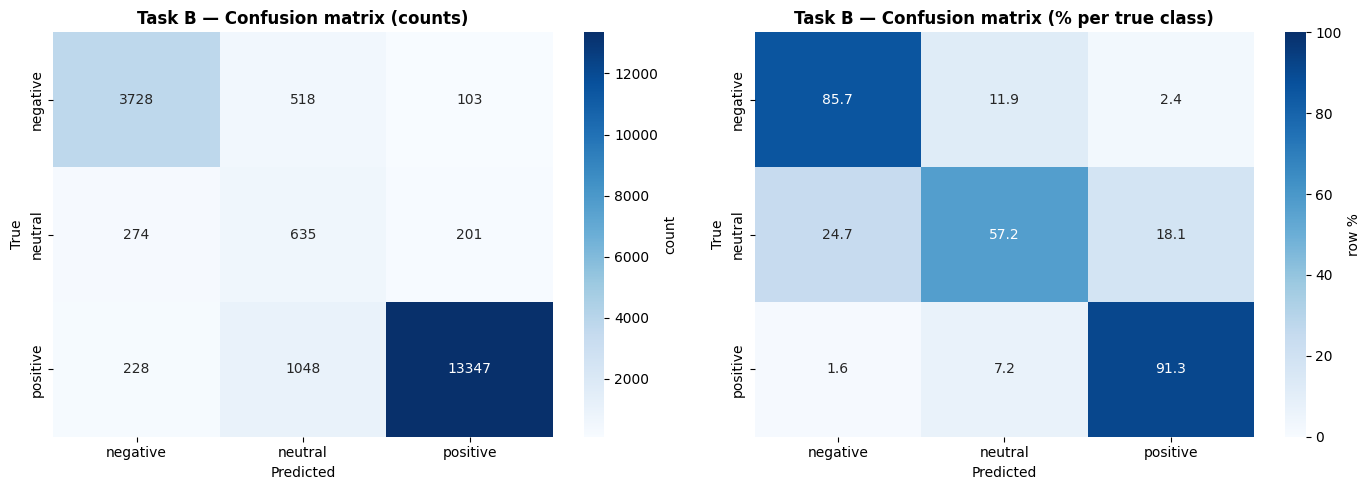

In [70]:
# Cell 16.2 — Confusion matrix + store predictions
print("Generating predictions for test set...")
preds_output_3 = trainer_3.predict(tokenized_3class["test"])
pred_labels_3 = np.argmax(preds_output_3.predictions, axis=-1)
true_labels_3 = preds_output_3.label_ids

distilbert_preds_3class = pred_labels_3.copy()

cm_3 = confusion_matrix(true_labels_3, pred_labels_3, labels=[0, 1, 2])
cm_3_pct = cm_3.astype(float) / cm_3.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_3, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names_3, yticklabels=class_names_3,
            ax=axes[0], cbar_kws={"label": "count"})
axes[0].set_title("Task B — Confusion matrix (counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_3_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_names_3, yticklabels=class_names_3,
            ax=axes[1], cbar_kws={"label": "row %"}, vmin=0, vmax=100)
axes[1].set_title("Task B — Confusion matrix (% per true class)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()

In [71]:
# Cell 16.3 — Per-class classification report
from sklearn.metrics import classification_report as cr_dict

report_3 = classification_report(
    true_labels_3, pred_labels_3,
    labels=[0, 1, 2], target_names=class_names_3,
    digits=4, zero_division=0,
)
print("=" * 70)
print("TASK B — PER-CLASS CLASSIFICATION REPORT")
print("=" * 70)
print(report_3)

report_3_dict = cr_dict(
    true_labels_3, pred_labels_3,
    labels=[0, 1, 2], target_names=class_names_3,
    output_dict=True, zero_division=0,
)

TASK B — PER-CLASS CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative     0.8813    0.8572    0.8691      4349
     neutral     0.2885    0.5721    0.3836      1110
    positive     0.9777    0.9127    0.9441     14623

    accuracy                         0.8819     20082
   macro avg     0.7159    0.7807    0.7323     20082
weighted avg     0.9188    0.8819    0.8969     20082



In [72]:
# Save Task B model + metrics + predictions to Drive
import json
import os

print("Saving Task B artefacts to Drive...")

trainer_3.save_model(DRIVE_FINAL_3)
tokenizer.save_pretrained(DRIVE_FINAL_3)

metrics_bundle_3 = {
    "task": "3-class sentiment (negative / neutral / positive)",
    "model": MODEL_NAME,
    "dataset": "MHARD",
    "num_labels": 3,
    "label_mapping": label_mapping_3class,
    "max_length": MAX_LENGTH,
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS_3,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "fp16": True,
        "class_weights": class_weights_3.tolist(),
        "metric_for_best_model": "f1_macro",
    },
    "splits": {
        "train": len(tokenized_3class["train"]),
        "validation": len(tokenized_3class["validation"]),
        "test": len(tokenized_3class["test"]),
    },
    "training": {
        "wall_time_seconds": float(training_time_3),
        "wall_time_minutes": float(training_time_3 / 60),
        "final_train_loss": float(train_result_3.training_loss),
        "global_steps": int(train_result_3.global_step),
        "best_val_f1_macro": float(trainer_3.state.best_metric),
        "emissions_kg_co2eq": float(emissions_3_train),
    },
    "test_results": {
        "accuracy":    float(test_results_3["eval_accuracy"]),
        "f1_weighted": float(test_results_3["eval_f1_weighted"]),
        "f1_macro":    float(test_results_3["eval_f1_macro"]),
        "loss":        float(test_results_3["eval_loss"]),
        "inference_seconds": float(inference_time_3),
        "throughput_samples_per_sec": float(n_test_3 / inference_time_3),
        "latency_ms_per_sample": float(ms_per_pred_3),
        "emissions_kg_co2eq": float(emissions_3_test),
        "emissions_mg_per_prediction": float(mg_per_pred_3),
        "majority_class_baseline_accuracy": float(majority_baseline),
    },
    "per_class_report": report_3_dict,
}

with open(f"{DRIVE_FINAL_3}/metrics_summary.json", "w") as f:
    json.dump(metrics_bundle_3, f, indent=2)

with open(f"{DRIVE_FINAL_3}/label_mapping.json", "w") as f:
    json.dump(label_mapping_3class, f, indent=2)

np.savez_compressed(
    f"{DRIVE_FINAL_3}/test_predictions.npz",
    pred_labels=distilbert_preds_3class,
    true_labels=true_labels_3,
    pred_logits=preds_output_3.predictions,
)

# Verify the save actually worked — same integrity check we learned from experience
files = os.listdir(DRIVE_FINAL_3)
assert "model.safetensors" in files, "CRITICAL: model.safetensors NOT saved!"
assert "metrics_summary.json" in files, "CRITICAL: metrics_summary.json NOT saved!"
print("Save integrity check PASSED. Model persisted to Drive.")

print(f"\nContents of {DRIVE_FINAL_3}:")
for fname in sorted(os.listdir(DRIVE_FINAL_3)):
    size_mb = os.path.getsize(os.path.join(DRIVE_FINAL_3, fname)) / (1024 * 1024)
    print(f"  - {fname:<30}  {size_mb:>8.2f} MB")

Saving Task B artefacts to Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Save integrity check PASSED. Model persisted to Drive.

Contents of /content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_3class_final:
  - config.json                         0.00 MB
  - label_mapping.json                  0.00 MB
  - metrics_summary.json                0.00 MB
  - model.safetensors                 255.43 MB
  - test_predictions.npz                0.14 MB
  - tokenizer.json                      0.68 MB
  - tokenizer_config.json               0.00 MB
  - training_args.bin                   0.01 MB


In [73]:
# Cell 16.5 — LLM head-to-head comparison (Task A + Task B)
# Verify alignment between DistilBERT predictions and the LLM predictions we
# locked in during the split step (test_llm_preds)
assert len(test_llm_preds) == len(distilbert_preds_5class) == len(distilbert_preds_3class), \
    "Prediction arrays length mismatch"

comparison_df = test_llm_preds.copy()
comparison_df["pred_distilbert"]        = distilbert_preds_5class + 1
comparison_df["pred_distilbert_3class"] = distilbert_preds_3class

def evaluate_model_5class(preds, truth):
    preds = pd.Series(preds).astype(float)
    truth = pd.Series(truth).astype(float)
    mask = preds.notna()
    p = preds[mask].astype(int).values
    t = truth[mask].astype(int).values
    return {
        "n_evaluated":  int(mask.sum()),
        "n_missing":    int((~mask).sum()),
        "accuracy":     accuracy_score(t, p),
        "f1_weighted":  f1_score(t, p, average="weighted", zero_division=0),
        "f1_macro":     f1_score(t, p, average="macro",    zero_division=0),
        "mae_stars":    mean_absolute_error(t, p),
    }

def evaluate_model_3class(preds, truth):
    preds = pd.Series(preds).astype(float)
    truth = pd.Series(truth).astype(float)
    mask = preds.notna()
    p = preds[mask].astype(int).values
    t = truth[mask].astype(int).values
    return {
        "n_evaluated":  int(mask.sum()),
        "n_missing":    int((~mask).sum()),
        "accuracy":     accuracy_score(t, p),
        "f1_weighted":  f1_score(t, p, average="weighted", zero_division=0),
        "f1_macro":     f1_score(t, p, average="macro",    zero_division=0),
    }

models_5 = [
    ("DistilBERT",       "pred_distilbert"),
    ("GPT-4",            "pred_gpt4"),
    ("LLaMA 3.3 70B",    "pred_llama3.3_70b"),
    ("Gemini 1.5 Pro",   "pred_gemini1.5pro"),
    ("GPT-3.5 Instruct", "pred_gpt3.5instruct"),
    ("GPT-3.5 Turbo",    "pred_gpt3.5turbo"),
    ("Gemini 1.5 Flash", "pred_gemini1.5flash"),
    ("LLaMA 3.1 8B",     "pred_llama3.1_8b"),
]
models_3 = [(name, col + "_3class") for name, col in models_5[1:]]
models_3.insert(0, ("DistilBERT", "pred_distilbert_3class"))

task_a_comparison = pd.DataFrame([
    {"model": name, **evaluate_model_5class(comparison_df[col], comparison_df["rating"])}
    for name, col in models_5
])
task_b_comparison = pd.DataFrame([
    {"model": name, **evaluate_model_3class(comparison_df[col], comparison_df["label_3class"])}
    for name, col in models_3
])

print("=" * 95)
print("TASK A (5-class) — HEAD-TO-HEAD on the identical test set")
print("=" * 95)
print(task_a_comparison.sort_values("accuracy", ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 95)
print("TASK B (3-class) — HEAD-TO-HEAD on the identical test set")
print("=" * 95)
print(task_b_comparison.sort_values("f1_macro", ascending=False)
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 95)

TASK A (5-class) — HEAD-TO-HEAD on the identical test set
           model  n_evaluated  n_missing  accuracy  f1_weighted  f1_macro  mae_stars
           GPT-4        20030         52    0.7494       0.7634    0.5676     0.3130
   LLaMA 3.3 70B        19995         87    0.7411       0.7524    0.5542     0.3309
  Gemini 1.5 Pro        20080          2    0.7386       0.7566    0.5791     0.3244
      DistilBERT        20082          0    0.7167       0.7422    0.5678     0.3489
GPT-3.5 Instruct        20045         37    0.6910       0.7230    0.5479     0.3726
   GPT-3.5 Turbo        20064         18    0.6661       0.7027    0.5162     0.4000
Gemini 1.5 Flash        19859        223    0.6080       0.6473    0.4876     0.5125
    LLaMA 3.1 8B        19043       1039    0.6072       0.6037    0.3551     0.6204

TASK B (3-class) — HEAD-TO-HEAD on the identical test set
           model  n_evaluated  n_missing  accuracy  f1_weighted  f1_macro
  Gemini 1.5 Pro        20080          2    

In [74]:
# Cell 16.6 — Save all comparison artefacts to Drive
comparison_output_dir = f"{DRIVE_BASE}/comparison"
os.makedirs(comparison_output_dir, exist_ok=True)

task_a_comparison.to_csv(f"{comparison_output_dir}/task_a_comparison.csv", index=False)
task_b_comparison.to_csv(f"{comparison_output_dir}/task_b_comparison.csv", index=False)
comparison_df.to_csv(f"{comparison_output_dir}/test_set_predictions_all_models.csv", index=False)

# Cohen's kappa vs ground truth for each model (5-class scale)
all_models_5 = models_5  # same as above
kappa_vs_truth = {}
for name, col in all_models_5:
    mask = comparison_df[col].notna()
    kappa_vs_truth[name] = cohen_kappa_score(
        comparison_df.loc[mask, "rating"].astype(int).values,
        comparison_df.loc[mask, col].astype(int).values,
    )
with open(f"{comparison_output_dir}/kappa_vs_truth.json", "w") as f:
    json.dump({k: float(v) for k, v in kappa_vs_truth.items()}, f, indent=2)

print(f"Comparison artefacts saved to: {comparison_output_dir}")
for fname in sorted(os.listdir(comparison_output_dir)):
    size_kb = os.path.getsize(os.path.join(comparison_output_dir, fname)) / 1024
    print(f"  - {fname:<45}  {size_kb:>8.1f} KB")

Comparison artefacts saved to: /content/drive/MyDrive/Colab Notebooks/DistilBERT/comparison
  - kappa_matrix_5class.csv                             1.3 KB
  - kappa_vs_truth.json                                 0.3 KB
  - task_a_comparison.csv                               0.8 KB
  - task_b_comparison.csv                               0.7 KB
  - test_set_predictions_all_models.csv              1412.7 KB


In [75]:
# Cell 16.7 — Final check + download-ready confirmation
print("=" * 70)
print("EVERYTHING PERSISTED TO DRIVE — SAFE TO DOWNLOAD NOTEBOOK")
print("=" * 70)

final_inventory = {}
for folder in [DRIVE_FINAL_5, DRIVE_FINAL_3, f"{DRIVE_BASE}/emissions", f"{DRIVE_BASE}/comparison"]:
    if os.path.isdir(folder):
        files = [f for f in os.listdir(folder) if not f.startswith(".")]
        final_inventory[folder] = files
        print(f"\n{folder}:")
        for f in sorted(files):
            size_mb = os.path.getsize(os.path.join(folder, f)) / (1024 * 1024)
            print(f"  ✓ {f:<35}  {size_mb:>8.2f} MB")

# Critical file presence checks — fail loudly if anything is missing
critical = {
    DRIVE_FINAL_5: ["model.safetensors", "metrics_summary.json", "label_mapping.json"],
    DRIVE_FINAL_3: ["model.safetensors", "metrics_summary.json", "label_mapping.json",
                     "test_predictions.npz"],
    f"{DRIVE_BASE}/comparison": ["task_a_comparison.csv", "task_b_comparison.csv",
                                  "test_set_predictions_all_models.csv",
                                  "kappa_vs_truth.json"],
}
missing_critical = []
for folder, expected in critical.items():
    present = final_inventory.get(folder, [])
    for f in expected:
        if f not in present:
            missing_critical.append(f"{folder}/{f}")

if missing_critical:
    print("\n!!! MISSING CRITICAL FILES — DO NOT CLOSE NOTEBOOK YET !!!")
    for m in missing_critical:
        print(f"  X {m}")
else:
    print("\n" + "=" * 70)
    print("ALL CRITICAL FILES SAFELY ON MY DRIVE")
    print("=" * 70)

EVERYTHING PERSISTED TO DRIVE — SAFE TO DOWNLOAD NOTEBOOK

/content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_5class_final:
  ✓ config.json                              0.00 MB
  ✓ label_mapping.json                       0.00 MB
  ✓ metrics_summary.json                     0.00 MB
  ✓ model.safetensors                      255.43 MB
  ✓ test_predictions.npz                     0.23 MB
  ✓ tokenizer.json                           0.68 MB
  ✓ tokenizer_config.json                    0.00 MB
  ✓ training_args.bin                        0.01 MB

/content/drive/MyDrive/Colab Notebooks/DistilBERT/distilbert_3class_final:
  ✓ config.json                              0.00 MB
  ✓ label_mapping.json                       0.00 MB
  ✓ metrics_summary.json                     0.00 MB
  ✓ model.safetensors                      255.43 MB
  ✓ test_predictions.npz                     0.14 MB
  ✓ tokenizer.json                           0.68 MB
  ✓ tokenizer_config.json                    0.0

In [76]:
import json

path = "/content/drive/MyDrive/Colab Notebooks/DistilBERT/Reducing_AI_Carbon_Footprint_A_Study_of_DistilBERT_for_Mental_Health_Sentiment_Analysis.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)

nb["metadata"].pop("widgets", None)

with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Done. Re-download and upload to GitHub.")

Done. Re-download and upload to GitHub.
